In [25]:
import sys
import os
import pandas as pd

sys.path.append('c:\\Users\\andres\\Desktop\\SEPTIMO SEMESTRE\\MONITORIA\\analisis')

import connection as conn

co=conn.connect()

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns



### Q1: What is the predominant biological sex and age group (life cycle) of smokers observed on campus?

In [27]:
df=pd.read_sql("""
SELECT * FROM question_question as q
JOIN response_response as r
ON r.question_id = q.id
WHERE q.parent_question_id= 2
OR q.parent_question_id = 9
""",co)

In [28]:
df

,id,code,question_type,description,parent_question_id,subcategory_id,is_required,position,input_type,id,numeric_value,text_value,option_id,question_id,visita_id
0,3,B.2,matrix_child,Hombre,2,1,1,2.0,NUM,3949,1,None,2,3,122
1,3,B.2,matrix_child,Hombre,2,1,1,2.0,NUM,4092,3,None,4,3,123
2,4,B.1,matrix_child,Mujer,2,1,1,1.0,NUM,3950,1,None,2,4,122
3,4,B.1,matrix_child,Mujer,2,1,1,1.0,NUM,4093,1,None,2,4,123
4,33,B.4,matrix_child,Expresión mixta/no definida,2,1,1,4.0,NUM,3968,1,None,2,33,122
5,33,B.4,matrix_child,Expresión mixta/no definida,2,1,1,4.0,NUM,4111,1,None,2,33,123
6,34,B.5,matrix_child,Indeterminada,2,1,1,5.0,NUM,3969,2,None,3,34,122
7,34,B.5,matrix_child,Indeterminada,2,1,1,5.0,NUM,4112,4,None,5,34,123
8,10,D.1,matrix_child,Adolescente (12-18 años),9,1,1,1.0,NUM,3954,2,None,3,10,122
9,10,D.1,matrix_child,Adolescente (12-18 años),9,1,1,1.0,NUM,4097,5,None,6,10,123


QUESTION: What is the predominant biological sex and
          age group of smokers observed on campus?

── BIOLOGICAL SEX ──────────────────────────────────────
Observed counts:
description
Expresión mixta/no definida    2
Hombre                         4
Indeterminada                  6
Mujer                          2

Total observed: 14
Predominant category: Indeterminada (n=6)

Chi-square Goodness of Fit:
  chi2 = 3.1429
  p-value = 0.3701
  ⚠️  Result: No significant difference between categories (p >= 0.05)

Fisher's Exact Test (Hombre vs Mujer only, excluding undefined):
  Hombre: 4  |  Mujer: 2
  Odds Ratio = 4.0000
  p-value = 0.5671
  ⚠️  No significant difference between men and women (p >= 0.05)

── AGE GROUPS (LIFE CYCLE) ─────────────────────────────
Observed counts:
description
Adolescente (12-18 años)    7
Joven(14-26 años)           6
Adulto (27-59 años)         7
Adulto Mayor (> 60 años)    5

Total observed: 25
Predominant category: Adolescente (12-18 años) (n=7)

C

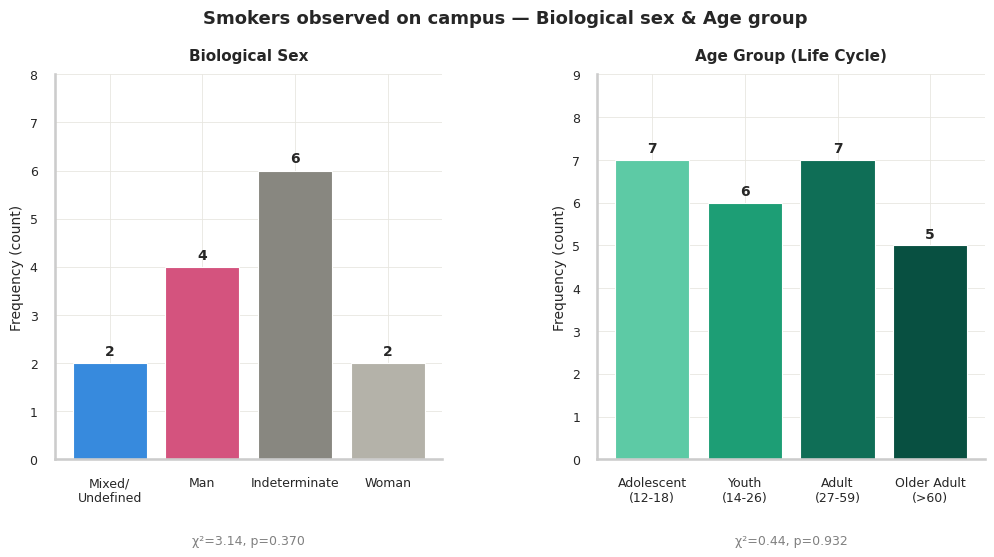

In [29]:

from scipy.stats import chisquare, fisher_exact
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

sex_codes = ['B.1', 'B.2', 'B.4', 'B.5']
age_codes = ['D.1', 'D.2', 'D.3', 'D.4']
 
sex_df = df[df['code'].isin(sex_codes)].groupby('description')['numeric_value'].sum()
age_df = df[df['code'].isin(age_codes)].groupby('description')['numeric_value'].sum()
 
# Reorder age groups logically
age_order = ['Adolescente (12-18 años)', 'Joven(14-26 años)',
             'Adulto (27-59 años)', 'Adulto Mayor (> 60 años)']
age_df = age_df.reindex(age_order)
 
# ── 2. Chi-square Goodness of Fit ─────────────────────────────────────────────
print("=" * 60)
print("QUESTION: What is the predominant biological sex and")
print("          age group of smokers observed on campus?")
print("=" * 60)
 
# --- Biological Sex ---
print("\n── BIOLOGICAL SEX ──────────────────────────────────────")
print(f"Observed counts:\n{sex_df.to_string()}")
print(f"\nTotal observed: {sex_df.sum()}")
print(f"Predominant category: {sex_df.idxmax()} (n={sex_df.max()})")
 
chi2_sex, p_sex = chisquare(sex_df.values)
print(f"\nChi-square Goodness of Fit:")
print(f"  chi2 = {chi2_sex:.4f}")
print(f"  p-value = {p_sex:.4f}")
if p_sex < 0.05:
    print("  ✅ Result: Significant difference — one sex predominates (p < 0.05)")
else:
    print("  ⚠️  Result: No significant difference between categories (p >= 0.05)")
 
# Fisher's exact for binary sex comparison (Hombre vs Mujer only)
print("\nFisher's Exact Test (Hombre vs Mujer only, excluding undefined):")
hombre = sex_df.get('Hombre', 0)
mujer  = sex_df.get('Mujer', 0)
total  = hombre + mujer
# 2x2 contingency: [smokers, non-smokers proxy] — comparing proportions
table = [[hombre, total - hombre], [mujer, total - mujer]]
odds_ratio, p_fisher = fisher_exact([[hombre, mujer], [mujer, hombre]])
print(f"  Hombre: {hombre}  |  Mujer: {mujer}")
print(f"  Odds Ratio = {odds_ratio:.4f}")
print(f"  p-value = {p_fisher:.4f}")
if p_fisher < 0.05:
    print("  ✅ Significant difference between men and women (p < 0.05)")
else:
    print("  ⚠️  No significant difference between men and women (p >= 0.05)")
 
# --- Age Groups ---
print("\n── AGE GROUPS (LIFE CYCLE) ─────────────────────────────")
print(f"Observed counts:\n{age_df.to_string()}")
print(f"\nTotal observed: {age_df.sum()}")
print(f"Predominant category: {age_df.idxmax()} (n={age_df.max()})")
 
chi2_age, p_age = chisquare(age_df.values)
print(f"\nChi-square Goodness of Fit:")
print(f"  chi2 = {chi2_age:.4f}")
print(f"  p-value = {p_age:.4f}")
if p_age < 0.05:
    print("  ✅ Result: Significant difference — one age group predominates (p < 0.05)")
else:
    print("  ⚠️  Result: No significant difference between age groups (p >= 0.05)")
 
# ── 3. Summary ────────────────────────────────────────────────────────────────
print("\n── FINAL ANSWER ────────────────────────────────────────")
print(f"  Predominant biological sex : {sex_df.idxmax()} (n={sex_df.max()})")
print(f"  Predominant age group      : {age_df.idxmax()} (n={age_df.max()})")
print(f"\n  ⚠️  Note: Sample size is very small (2 visits).")
print(f"      Interpret results with caution.")
 
# ── 4. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 5))
fig.suptitle("Smokers observed on campus — Biological sex & Age group",
             fontsize=13, fontweight='bold', y=1.01)
 
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)
 
colors_sex = ['#378ADD', '#D4537E', '#888780', '#B4B2A9']
colors_age = ['#5DCAA5', '#1D9E75', '#0F6E56', '#085041']
 
# Sex chart
ax1 = fig.add_subplot(gs[0])
bars1 = ax1.bar(sex_df.index, sex_df.values, color=colors_sex, edgecolor='white', linewidth=0.8)
ax1.set_title("Biological Sex", fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel("Frequency (count)", fontsize=10)
ax1.set_xticks(range(len(sex_df)))
ax1.set_xticklabels(['Mixed/\nUndefined', 'Man', 'Indeterminate', 'Woman'],
                     fontsize=9)
ax1.set_ylim(0, sex_df.max() + 2)
for bar, val in zip(bars1, sex_df.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.text(0.5, -0.22,
         f"χ²={chi2_sex:.2f}, p={p_sex:.3f}",
         ha='center', transform=ax1.transAxes, fontsize=9, color='gray')
ax1.spines[['top','right']].set_visible(False)
 
# Age chart
ax2 = fig.add_subplot(gs[1])
short_labels = ['Adolescent\n(12-18)', 'Youth\n(14-26)', 'Adult\n(27-59)', 'Older Adult\n(>60)']
bars2 = ax2.bar(short_labels, age_df.values, color=colors_age, edgecolor='white', linewidth=0.8)
ax2.set_title("Age Group (Life Cycle)", fontsize=11, fontweight='bold', pad=10)
ax2.set_ylabel("Frequency (count)", fontsize=10)
ax2.set_ylim(0, age_df.max() + 2)
for bar, val in zip(bars2, age_df.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.text(0.5, -0.22,
         f"χ²={chi2_age:.2f}, p={p_age:.3f}",
         ha='center', transform=ax2.transAxes, fontsize=9, color='gray')
ax2.spines[['top','right']].set_visible(False)
 
plt.tight_layout()
plt.savefig('smokers_analysis.png', dpi=150, bbox_inches='tight')
print("\n✅ Chart saved as smokers_analysis.png")

PREDOMINANT PROFILE: count_undefined and count_adulto


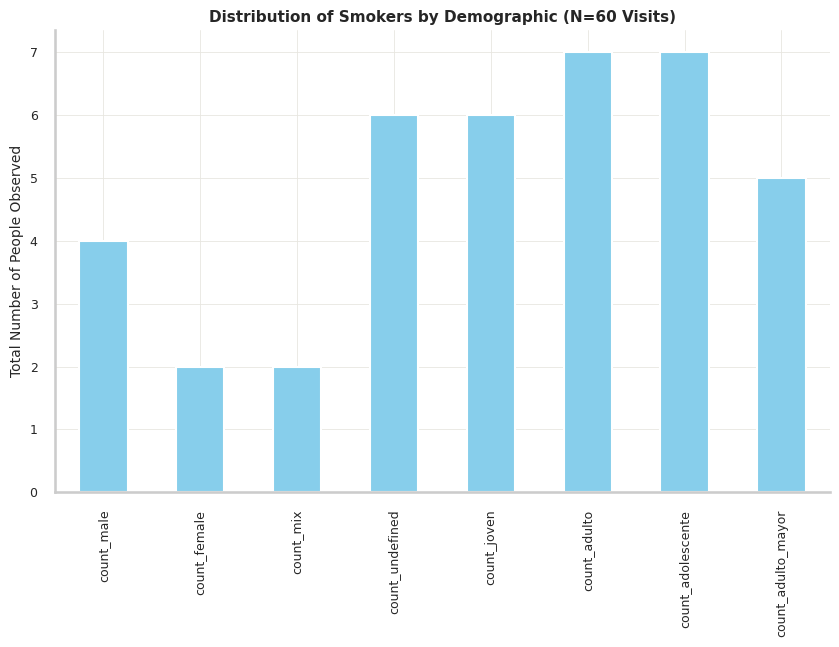

In [30]:
# descriptive statistics and frecuency distributions

df= pd.read_sql("""
SELECT 
    v.id AS visit_id,
    -- Sex Counts
    SUM(CASE WHEN r.question_id = 3 THEN r.numeric_value ELSE 0 END) AS count_male,
    SUM(CASE WHEN r.question_id = 4 THEN r.numeric_value ELSE 0 END) AS count_female,
    SUM(CASE WHEN r.question_id = 33 THEN r.numeric_value ELSE 0 END) AS count_mix,
    SUM(CASE WHEN r.question_id = 34 THEN r.numeric_value ELSE 0 END) AS count_undefined,
                
    -- Age Group Counts
    SUM(CASE WHEN r.question_id = 10 THEN r.numeric_value ELSE 0 END) AS count_adolescente,
    SUM(CASE WHEN r.question_id = 11 THEN r.numeric_value ELSE 0 END) AS count_joven,
    SUM(CASE WHEN r.question_id = 12 THEN r.numeric_value ELSE 0 END) AS count_adulto,
    SUM(CASE WHEN r.question_id = 13 THEN r.numeric_value ELSE 0 END) AS count_adulto_mayor
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id;
""",co)

# 1. Totalize the observations across all 60 visits
totals = df[['count_male', 'count_female','count_mix','count_undefined', 'count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']].sum()

# 2. Identify the Predominant Group
predominant_sex = totals[['count_male', 'count_female','count_mix','count_undefined']].idxmax()
predominant_age = totals[['count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']].idxmax()

print(f"PREDOMINANT PROFILE: {predominant_sex} and {predominant_age}")

# 3. Create a Composition Matrix (How Sex and Age overlap)
# This assumes you have mapped the individuals in your data processing
# If you don't have individual-level mapping, you use the aggregate sums:
sex_dist = totals[['count_male', 'count_female','count_mix','count_undefined']]
age_dist = totals[['count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']]

# Visualization
plt.figure(figsize=(10, 6))
totals.plot(kind='bar', color='skyblue')
plt.title("Distribution of Smokers by Demographic (N=60 Visits)")
plt.ylabel("Total Number of People Observed")
plt.show()

### Q2: What is the predominant  sex and ethnic/racial group  of smokers observed on campus?

In [31]:
df= pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value, q.parent_question_id 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id
WHERE q.parent_question_id IN (2, 5)
""", co)

Q2: What is the predominant sex and ethnic/racial group
    of smokers observed on campus?

── BIOLOGICAL SEX ──────────────────────────────────────────
Observed counts:
description
Hombre                         4
Mujer                          2
Expresión mixta/no definida    2
Indeterminada                  6

Total: 14
Predominant category: Indeterminada (n=6)

Chi-square Goodness of Fit:
  chi2    = 3.1429
  p-value = 0.3701
  Expected per category (if equal): 3.50
  ⚠️  Not significant: no sex predominates statistically (p ≥ 0.05)

Fisher's Exact Test (Hombre vs Mujer only):
  Hombre=4, Mujer=2
  Odds Ratio = 4.0000
  p-value    = 0.5671
  ⚠️  No significant difference between Hombre and Mujer.

── ETHNIC / RACIAL GROUP ───────────────────────────────────
Observed counts:
description
Mestizos           4
Indígena           6
Afrodecendiente    6

Total: 16
Predominant category: Indígena (n=6)

Chi-square Goodness of Fit:
  chi2    = 0.5000
  p-value = 0.7788
  Expected per catego

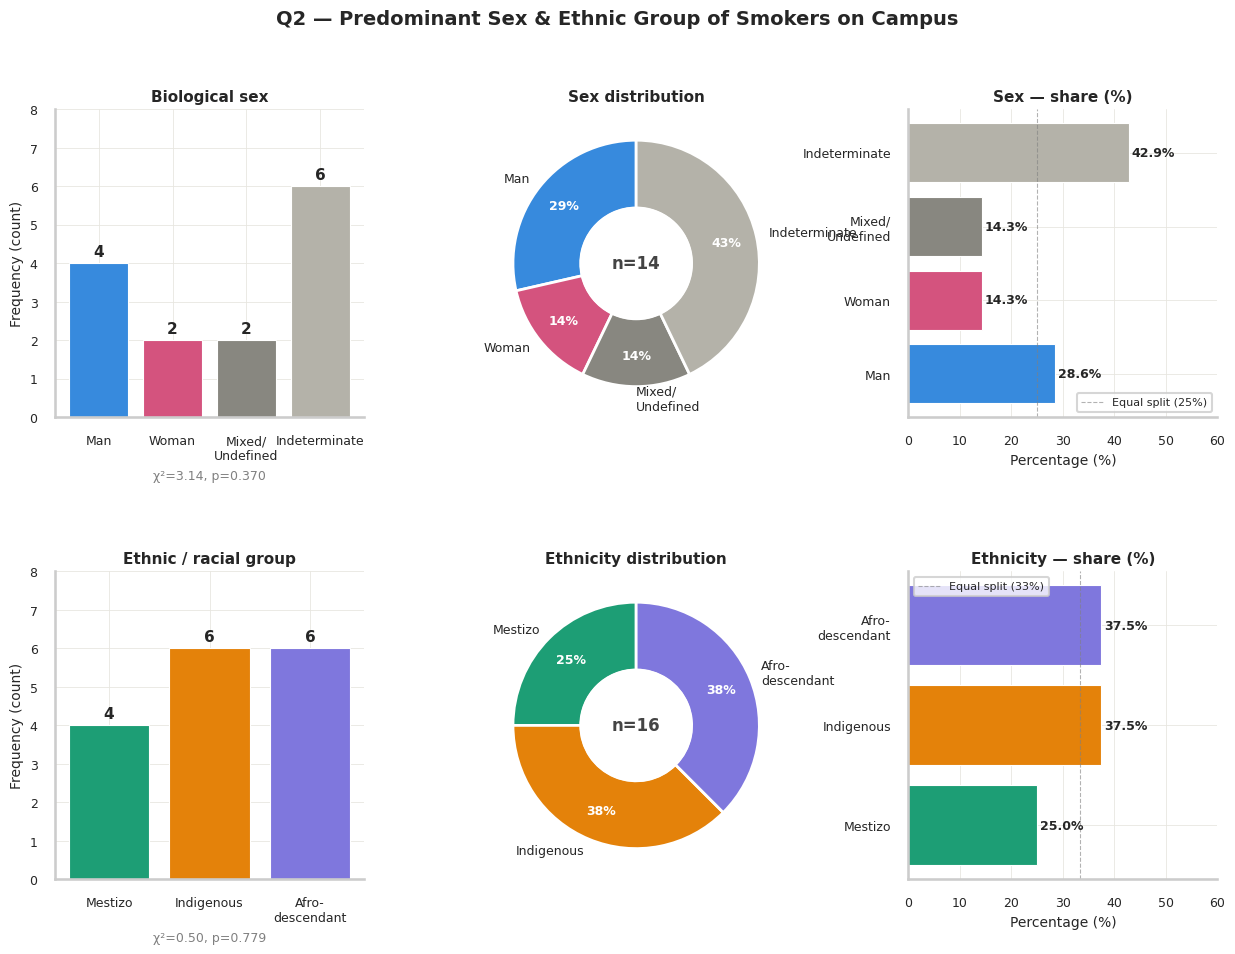

In [32]:
import pandas as pd
import numpy as np
from scipy.stats import chisquare, fisher_exact
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')



sex_df = df[df['parent_question_id'] == 2].groupby('description')['numeric_value'].sum()
eth_df = df[df['parent_question_id'] == 5].groupby('description')['numeric_value'].sum()

# Logical order
sex_order = ['Hombre', 'Mujer', 'Expresión mixta/no definida', 'Indeterminada']
eth_order = ['Mestizos', 'Indígena', 'Afrodecendiente']
sex_df = sex_df.reindex(sex_order)
eth_df = eth_df.reindex(eth_order)

sex_labels_short = ['Man', 'Woman', 'Mixed/\nUndefined', 'Indeterminate']
eth_labels_short = ['Mestizo', 'Indigenous', 'Afro-\ndescendant']

# ── 2. Print results ──────────────────────────────────────────────────────────
print("=" * 62)
print("Q2: What is the predominant sex and ethnic/racial group")
print("    of smokers observed on campus?")
print("=" * 62)

# --- BIOLOGICAL SEX ---
print("\n── BIOLOGICAL SEX ──────────────────────────────────────────")
print(f"Observed counts:\n{sex_df.to_string()}")
print(f"\nTotal: {sex_df.sum()}")
print(f"Predominant category: {sex_df.idxmax()} (n={sex_df.max()})")

chi2_sex, p_sex = chisquare(sex_df.values)
print(f"\nChi-square Goodness of Fit:")
print(f"  chi2    = {chi2_sex:.4f}")
print(f"  p-value = {p_sex:.4f}")
exp_sex = sex_df.sum() / len(sex_df)
print(f"  Expected per category (if equal): {exp_sex:.2f}")
if p_sex < 0.05:
    print(f"  ✅ Significant: one sex category predominates (p < 0.05)")
else:
    print(f"  ⚠️  Not significant: no sex predominates statistically (p ≥ 0.05)")

# Fisher's exact — Hombre vs Mujer only
print(f"\nFisher's Exact Test (Hombre vs Mujer only):")
h_val = sex_df['Hombre']
m_val = sex_df['Mujer']
tot   = h_val + m_val
table_2x2 = [[h_val, m_val], [m_val, h_val]]
or_sex, p_fisher_sex = fisher_exact([[h_val, tot - h_val],
                                      [m_val, tot - m_val]])
print(f"  Hombre={h_val}, Mujer={m_val}")
print(f"  Odds Ratio = {or_sex:.4f}")
print(f"  p-value    = {p_fisher_sex:.4f}")
if p_fisher_sex < 0.05:
    print(f"  ✅ Significant difference between Hombre and Mujer.")
else:
    print(f"  ⚠️  No significant difference between Hombre and Mujer.")

# --- ETHNICITY ---
print(f"\n── ETHNIC / RACIAL GROUP ───────────────────────────────────")
print(f"Observed counts:\n{eth_df.to_string()}")
print(f"\nTotal: {eth_df.sum()}")
print(f"Predominant category: {eth_df.idxmax()} (n={eth_df.max()})")

chi2_eth, p_eth = chisquare(eth_df.values)
exp_eth = eth_df.sum() / len(eth_df)
print(f"\nChi-square Goodness of Fit:")
print(f"  chi2    = {chi2_eth:.4f}")
print(f"  p-value = {p_eth:.4f}")
print(f"  Expected per category (if equal): {exp_eth:.2f}")
if p_eth < 0.05:
    print(f"  ✅ Significant: one ethnic group predominates (p < 0.05)")
else:
    print(f"  ⚠️  Not significant: no ethnic group predominates statistically (p ≥ 0.05)")

# --- FINAL ANSWER ---
print(f"\n── FINAL ANSWER ────────────────────────────────────────────")
print(f"  Predominant biological sex  : {sex_df.idxmax()} (n={sex_df.max()}, "
      f"{sex_df.max()/sex_df.sum()*100:.1f}%)")
print(f"  Predominant ethnic group    : {eth_df.idxmax()} (n={eth_df.max()}, "
      f"{eth_df.max()/eth_df.sum()*100:.1f}%)")
print(f"\n  ⚠️  Sample size is very small (2 visits). Interpret with caution.")

# ── 3. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
fig.suptitle("Q2 — Predominant Sex & Ethnic Group of Smokers on Campus",
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

COLOR_SEX = ['#378ADD', '#D4537E', '#888780', '#B4B2A9']
COLOR_ETH = ['#1D9E75', '#E4820A', '#7F77DD']

# ── Plot 1: Sex bar chart
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(range(len(sex_df)), sex_df.values,
               color=COLOR_SEX, edgecolor='white', linewidth=0.8)
ax1.set_xticks(range(len(sex_df)))
ax1.set_xticklabels(sex_labels_short, fontsize=9)
ax1.set_ylabel('Frequency (count)', fontsize=10)
ax1.set_title('Biological sex', fontsize=11, fontweight='bold')
ax1.set_ylim(0, sex_df.max() + 2)
ax1.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, sex_df.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.text(0.5, -0.20, f"χ²={chi2_sex:.2f}, p={p_sex:.3f}",
         ha='center', transform=ax1.transAxes, fontsize=9, color='gray')

# ── Plot 2: Sex donut
ax2 = fig.add_subplot(gs[0, 1])
wedges, texts, autotexts = ax2.pie(
    sex_df.values, labels=sex_labels_short, colors=COLOR_SEX,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold'); at.set_color('white')
centre = plt.Circle((0, 0), 0.45, fc='white')
ax2.add_artist(centre)
ax2.text(0, 0, f'n={sex_df.sum()}', ha='center', va='center',
         fontsize=12, fontweight='bold', color='#444')
ax2.set_title('Sex distribution', fontsize=11, fontweight='bold')

# ── Plot 3: Sex % horizontal bar
ax3 = fig.add_subplot(gs[0, 2])
pct_sex = (sex_df.values / sex_df.sum() * 100)
colors_sorted = [COLOR_SEX[i] for i in range(len(sex_df))]
hbars = ax3.barh(range(len(sex_df)), pct_sex,
                  color=COLOR_SEX, edgecolor='white', linewidth=0.8)
ax3.set_yticks(range(len(sex_df)))
ax3.set_yticklabels(sex_labels_short, fontsize=9)
ax3.set_xlabel('Percentage (%)', fontsize=10)
ax3.set_title('Sex — share (%)', fontsize=11, fontweight='bold')
ax3.set_xlim(0, 60)
ax3.spines[['top', 'right']].set_visible(False)
ax3.axvline(100/len(sex_df), color='gray', linestyle='--',
            linewidth=0.8, alpha=0.6, label=f'Equal split ({100/len(sex_df):.0f}%)')
ax3.legend(fontsize=8)
for bar, val in zip(hbars, pct_sex):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# ── Plot 4: Ethnicity bar chart
ax4 = fig.add_subplot(gs[1, 0])
bars2 = ax4.bar(range(len(eth_df)), eth_df.values,
                color=COLOR_ETH, edgecolor='white', linewidth=0.8)
ax4.set_xticks(range(len(eth_df)))
ax4.set_xticklabels(eth_labels_short, fontsize=9)
ax4.set_ylabel('Frequency (count)', fontsize=10)
ax4.set_title('Ethnic / racial group', fontsize=11, fontweight='bold')
ax4.set_ylim(0, eth_df.max() + 2)
ax4.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars2, eth_df.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.text(0.5, -0.20, f"χ²={chi2_eth:.2f}, p={p_eth:.3f}",
         ha='center', transform=ax4.transAxes, fontsize=9, color='gray')

# ── Plot 5: Ethnicity donut
ax5 = fig.add_subplot(gs[1, 1])
wedges2, texts2, autotexts2 = ax5.pie(
    eth_df.values, labels=eth_labels_short, colors=COLOR_ETH,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts2:
    at.set_fontsize(9); at.set_fontweight('bold'); at.set_color('white')
centre2 = plt.Circle((0, 0), 0.45, fc='white')
ax5.add_artist(centre2)
ax5.text(0, 0, f'n={eth_df.sum()}', ha='center', va='center',
         fontsize=12, fontweight='bold', color='#444')
ax5.set_title('Ethnicity distribution', fontsize=11, fontweight='bold')

# ── Plot 6: Ethnicity % horizontal bar
ax6 = fig.add_subplot(gs[1, 2])
pct_eth = (eth_df.values / eth_df.sum() * 100)
hbars2 = ax6.barh(range(len(eth_df)), pct_eth,
                   color=COLOR_ETH, edgecolor='white', linewidth=0.8)
ax6.set_yticks(range(len(eth_df)))
ax6.set_yticklabels(eth_labels_short, fontsize=9)
ax6.set_xlabel('Percentage (%)', fontsize=10)
ax6.set_title('Ethnicity — share (%)', fontsize=11, fontweight='bold')
ax6.set_xlim(0, 60)
ax6.spines[['top', 'right']].set_visible(False)
ax6.axvline(100/len(eth_df), color='gray', linestyle='--',
            linewidth=0.8, alpha=0.6, label=f'Equal split ({100/len(eth_df):.0f}%)')
ax6.legend(fontsize=8)
for bar, val in zip(hbars2, pct_eth):
    ax6.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.savefig('q2_sex_ethnicity.png', dpi=150, bbox_inches='tight')
print("\n✅ Chart saved as q2_sex_ethnicity.png")

In [33]:
#chi square test

from scipy.stats import chi2_contingency

sex_vars = df[df['parent_question_id'] == 2]['description'].unique()
ethnic_vars = df[df['parent_question_id'] == 5]['description'].unique()

# 2. Pivot
pivot_df = df.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

sex_totals=pivot_df[sex_vars].sum()
ethnic_totals=pivot_df[ethnic_vars].sum()

observed = []

for sex in sex_vars:
    row = []
    for ethnic in ethnic_vars:
        
        val = (sex_totals[sex] * ethnic_totals[ethnic]) / sex_totals.sum()
        row.append(val)
    observed.append(row)

contingency_df = pd.DataFrame(observed, index=sex_vars, columns=ethnic_vars)


stat, p, dof, expected = chi2_contingency(contingency_df)

print(f"Chi-Square Statistic: {stat:.2f}")
print(f"P-value: {p:.4f}")



Chi-Square Statistic: 0.00
P-value: 1.0000


### Q3: Are there specific demographics that are more likely to use electronic cigarettes/vapes (Question E.2) vs  traditional cigarettes (Question E.1) vs Marihuana?

Q3: Are certain demographics more likely to use each substance?
    Cigarette (E.1) | Vape (E.2) | Marihuana (E.3)

Raw totals across all visits:
  Cigarette (E.1)     : 7
  Vape (E.2)          : 5
  Marihuana           : 7

Sex counts:
  Hombre                             : 4
  Mujer                              : 2
  Expresión mixta/no definida        : 2
  Indeterminada                      : 6

── CONTINGENCY TABLE (proportional distribution) ─────────────
                             Cigarette (E.1)  Vape (E.2)  Marihuana
Hombre                                  2.07        1.53       2.20
Mujer                                   0.96        0.64       0.87
Expresión mixta/no definida             0.96        0.64       0.87
Indeterminada                           3.02        2.18       3.07

── CHI-SQUARE TEST OF INDEPENDENCE (4 demographics × 3 products) ──
  chi2    = 0.1587
  p-value = 0.9999
  df      = 6

  Expected frequencies:
                             Cigarette (E.1)  Vap

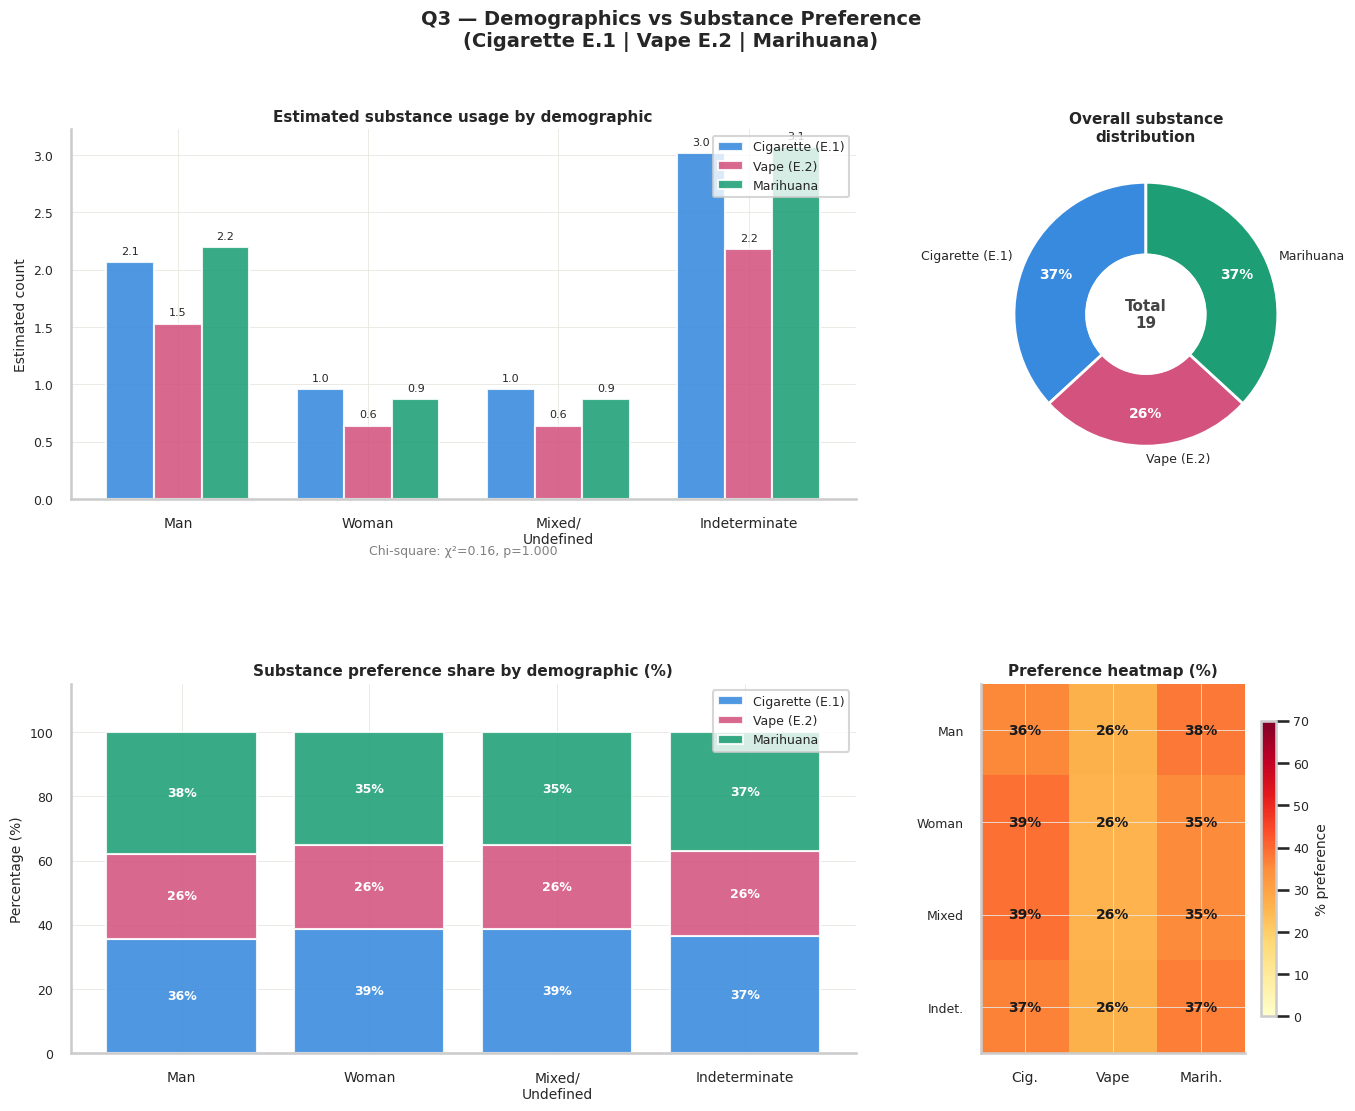

In [34]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

df= pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value, q.parent_question_id 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id
WHERE q.parent_question_id IN (2, 14)
""", co)

# 2. Pivot
df = df.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)


CIG_COL = 'Cigarrillo (especificar en comentarios que tipo de cigarrillo es, ej: herbal o de otro tipo)'
VAP_COL = 'Vapeador'
MAR_COL = 'Marihuana'

sex_cols     = ['Hombre', 'Mujer', 'Expresión mixta/no definida', 'Indeterminada']
product_cols = [CIG_COL, VAP_COL, MAR_COL]
prod_labels  = ['Cigarette (E.1)', 'Vape (E.2)', 'Marihuana']
short_sex    = ['Man', 'Woman', 'Mixed/\nUndefined', 'Indeterminate']
short_sex_h  = ['Man', 'Woman', 'Mixed', 'Indet.']   # for heatmap

COLORS = {
    'Cigarette (E.1)': '#378ADD',
    'Vape (E.2)'     : '#D4537E',
    'Marihuana'      : '#1D9E75',
}

# ── 2. Build proportional contingency table (all 3 products) ──────────────────
contingency = {s: {p: 0.0 for p in prod_labels} for s in sex_cols}

for _, row in df.iterrows():
    sex_sum = sum(row[s] for s in sex_cols)
    if sex_sum == 0:
        continue
    for s in sex_cols:
        weight = row[s] / sex_sum
        contingency[s]['Cigarette (E.1)'] += weight * row[CIG_COL]
        contingency[s]['Vape (E.2)']      += weight * row[VAP_COL]
        contingency[s]['Marihuana']        += weight * row[MAR_COL]

ct     = pd.DataFrame(contingency).T.round(2)
ct_int = ct.round().astype(int)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Raw totals
raw_totals = {
    'Cigarette (E.1)': df[CIG_COL].sum(),
    'Vape (E.2)'     : df[VAP_COL].sum(),
    'Marihuana'      : df[MAR_COL].sum(),
}

# ── 3. Statistical tests ──────────────────────────────────────────────────────
print("=" * 65)
print("Q3: Are certain demographics more likely to use each substance?")
print("    Cigarette (E.1) | Vape (E.2) | Marihuana (E.3)")
print("=" * 65)

print(f"\nRaw totals across all visits:")
for k, v in raw_totals.items():
    print(f"  {k:20s}: {v}")

print(f"\nSex counts:")
for s in sex_cols:
    print(f"  {s:35s}: {df[s].sum()}")

print(f"\n── CONTINGENCY TABLE (proportional distribution) ─────────────")
print(ct.to_string())

# Chi-square on full 4x3 table
print(f"\n── CHI-SQUARE TEST OF INDEPENDENCE (4 demographics × 3 products) ──")
chi2, p_chi2, dof, expected = chi2_contingency(ct_int.values)
print(f"  chi2    = {chi2:.4f}")
print(f"  p-value = {p_chi2:.4f}")
print(f"  df      = {dof}")
exp_df = pd.DataFrame(expected.round(2), index=ct.index, columns=ct.columns)
print(f"\n  Expected frequencies:\n{exp_df.to_string()}")
low_exp = (expected < 5).any()
print(f"\n  {'⚠️  Some expected freq < 5 — interpret with caution' if low_exp else '✅ All expected freq ≥ 5'}")
if p_chi2 < 0.05:
    print(f"  ✅ Significant association (p < 0.05): demographics are")
    print(f"     associated with substance preference.")
else:
    print(f"  ⚠️  No significant association (p = {p_chi2:.3f} ≥ 0.05).")
    print(f"     Cannot confirm demographics drive substance preference.")

# Pairwise Fisher's exact — Hombre vs Mujer for each product pair
print(f"\n── FISHER'S EXACT TEST (Hombre vs Mujer, pairwise products) ──")
pairs = [
    ('Cigarette (E.1)', 'Vape (E.2)'),
    ('Cigarette (E.1)', 'Marihuana'),
    ('Vape (E.2)',      'Marihuana'),
]
for p1, p2 in pairs:
    row_h = [ct_int.loc['Hombre', p1], ct_int.loc['Hombre', p2]]
    row_m = [ct_int.loc['Mujer',  p1], ct_int.loc['Mujer',  p2]]
    table = [row_h, row_m]
    try:
        or_, pf = fisher_exact(table)
        sig = "✅ Significant" if pf < 0.05 else "⚠️  Not significant"
        print(f"  {p1} vs {p2}:")
        print(f"    Hombre={row_h}, Mujer={row_m} | OR={or_:.3f}, p={pf:.4f} → {sig}")
    except Exception as e:
        print(f"  {p1} vs {p2}: could not compute ({e})")

# Preference % per demographic
print(f"\n── SUBSTANCE PREFERENCE BY DEMOGRAPHIC (%) ───────────────────")
print(ct_pct.round(1).to_string())

print(f"\n── FINAL ANSWER ───────────────────────────────────────────────")
for prod in prod_labels:
    dom = ct[prod].idxmax()
    print(f"  Most {prod:20s} users: {dom} ({ct.loc[dom, prod]:.1f} est.)")
print(f"\n  ⚠️  Proportional estimation — only 2 visits. Low statistical power.")

# ── 4. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "Q3 — Demographics vs Substance Preference\n(Cigarette E.1 | Vape E.2 | Marihuana)",
    fontsize=14, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)
x  = np.arange(len(sex_cols))
w  = 0.25

# ── Plot 1: Grouped bar chart — estimated counts
ax1 = fig.add_subplot(gs[0, :2])
offsets = [-w, 0, w]
for i, (prod, color) in enumerate(COLORS.items()):
    vals = ct[prod].values
    bars = ax1.bar(x + offsets[i], vals, w,
                   label=prod, color=color, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(short_sex, fontsize=10)
ax1.set_ylabel('Estimated count', fontsize=10)
ax1.set_title('Estimated substance usage by demographic', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.spines[['top', 'right']].set_visible(False)
ax1.text(0.5, -0.15, f"Chi-square: χ²={chi2:.2f}, p={p_chi2:.3f}",
         ha='center', transform=ax1.transAxes, fontsize=9, color='gray')

# ── Plot 2: Overall totals donut chart
ax2 = fig.add_subplot(gs[0, 2])
donut_vals   = list(raw_totals.values())
donut_colors = list(COLORS.values())
wedges, texts, autotexts = ax2.pie(
    donut_vals, labels=prod_labels, colors=donut_colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
centre = plt.Circle((0, 0), 0.45, fc='white')
ax2.add_artist(centre)
total_all = sum(donut_vals)
ax2.text(0, 0, f'Total\n{total_all}', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#444')
ax2.set_title('Overall substance\ndistribution', fontsize=11, fontweight='bold')

# ── Plot 3: Stacked % bar per demographic
ax3 = fig.add_subplot(gs[1, :2])
bottom = np.zeros(len(sex_cols))
for prod, color in COLORS.items():
    vals = ct_pct[prod].values
    bars = ax3.bar(x, vals, bottom=bottom, label=prod,
                   color=color, alpha=0.88, edgecolor='white')
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 8:
            ax3.text(bar.get_x() + bar.get_width()/2,
                     bottom[i] + val/2,
                     f'{val:.0f}%', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')
    bottom += vals
ax3.set_xticks(x)
ax3.set_xticklabels(short_sex, fontsize=10)
ax3.set_ylabel('Percentage (%)', fontsize=10)
ax3.set_ylim(0, 115)
ax3.set_title('Substance preference share by demographic (%)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9, loc='upper right')
ax3.spines[['top', 'right']].set_visible(False)

# ── Plot 4: Heatmap of % preference
ax4 = fig.add_subplot(gs[1, 2])
heatmap_data = ct_pct.values
im = ax4.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=70)
ax4.set_xticks(range(3))
ax4.set_xticklabels(['Cig.', 'Vape', 'Marih.'], fontsize=10)
ax4.set_yticks(range(len(sex_cols)))
ax4.set_yticklabels(short_sex_h, fontsize=9)
ax4.set_title('Preference heatmap (%)', fontsize=11, fontweight='bold')
for i in range(len(sex_cols)):
    for j in range(3):
        val = heatmap_data[i, j]
        color = 'white' if val > 40 else '#1a1a1a'
        ax4.text(j, i, f'{val:.0f}%', ha='center', va='center',
                 fontsize=10, fontweight='bold', color=color)
plt.colorbar(im, ax=ax4, shrink=0.8, label='% preference')

plt.savefig('q3_all_substances.png', dpi=150, bbox_inches='tight')
print("\n✅ Chart saved as q3_all_substances.png")





### Q4: Which Zones (from zone_zone) have the highest density of smokers per observation hour?

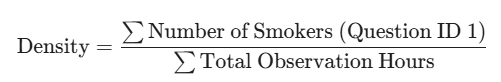

In [35]:
df=pd.read_sql("""
SELECT 
    z.id AS zone_id,           
    z.name AS zone_name,
    SUM(r.numeric_value) AS total_smokers,
    -- Calculate duration in hours
    SUM(TIMESTAMPDIFF(MINUTE, v.visit_start_date_time, v.visit_end_date_time) / 60.0) AS total_hours
FROM response_response r
JOIN visit_visit v ON r.visita_id = v.id
JOIN surveysession_surveysession s ON v.surveysession_id = s.id
JOIN zone_zone z ON s.zone_id = z.id
WHERE r.question_id = 1 -- Question: "Número de personas que se observaron fumando"
GROUP BY z.name,z.id
HAVING total_hours > 0;
""",co)

df['smoker_density'] = df['total_smokers'] / df['total_hours']

# 3. Sort by the highest density
df_ranked = df.sort_values(by='smoker_density', ascending=False)

# 4. Filter for Top 5 hotspots
top_hotspots = df_ranked.head(5)

print("### TOP SMOKING HOTSPOTS (Density per Hour) ###")
print(top_hotspots[['zone_name', 'smoker_density']])

### TOP SMOKING HOTSPOTS (Density per Hour) ###
                                           zone_name  smoker_density
1            Central, pasillos de central y banderas            40.0
0  Plazoleta de ingenierías, pasillos de la Escue...             0.0


In [36]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. The ANOVA test
# We group the smokers_per_hour by zone_name
zones = [group['total_smokers'].values for name, group in df.groupby('zone_name')]
f_stat, p_val = f_oneway(*zones)

print(f"ANOVA P-value: {p_val:.4f}")

# 2. If P < 0.05, we find the 'Winner' using Tukey HSD
if p_val < 0.05:
    print("Significant difference found! Performing Post-Hoc analysis...")
    tukey = pairwise_tukeyhsd(endog=df['smokers_per_hour'], 
                              groups=df['zone_name'], 
                              alpha=0.05)
    print(tukey)



ANOVA P-value: nan


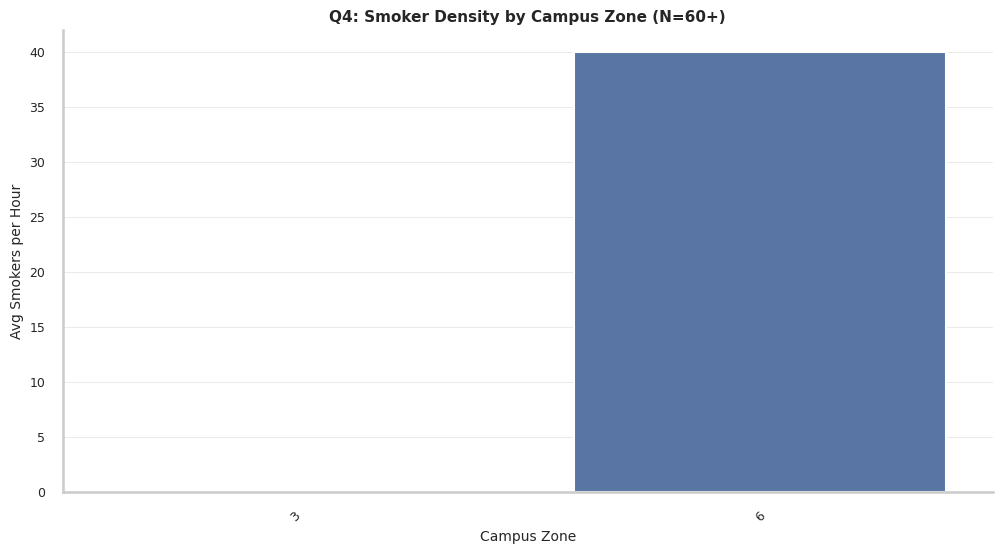

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(x='zone_id', y='smoker_density', data=df, capsize=.2)
plt.title("Q4: Smoker Density by Campus Zone (N=60+)")
plt.ylabel("Avg Smokers per Hour")
plt.xlabel("Campus Zone")
plt.xticks(rotation=45)
plt.show()

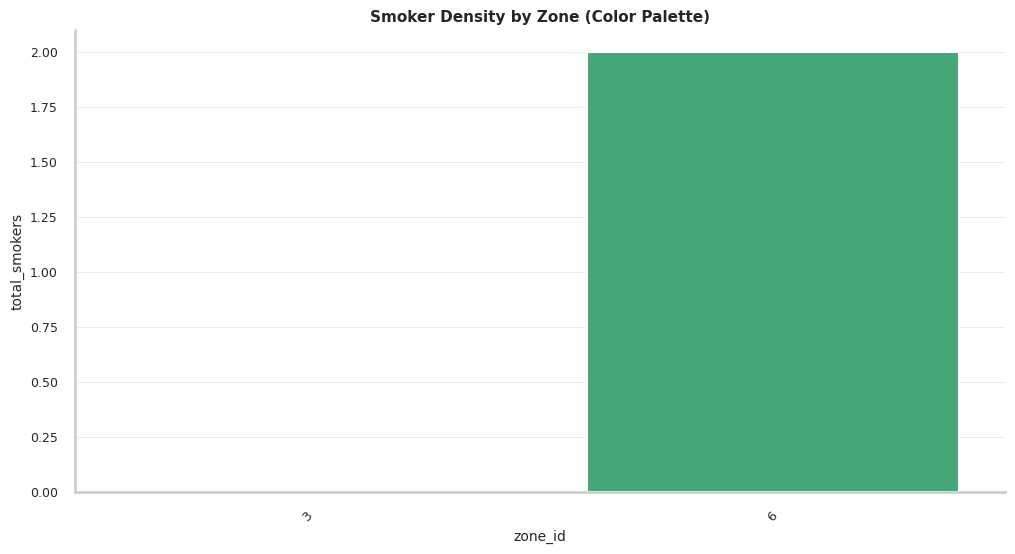

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))


sns.barplot(
    x='zone_id', 
    y='total_smokers', 
    data=df, 
    palette='viridis', 
    hue='zone_name', 
    legend=False
)

plt.title("Smoker Density by Zone (Color Palette)")
plt.xticks(rotation=45)
plt.show()

### Q5: How often do vulnerable populations (Children and Pregnant Women - Questions T & U) coincide in the same zones as active smokers?

In [39]:
df=pd.read_sql("""
SELECT 
    v.id AS visita_id,
    z.name AS zone_name,
    r1.numeric_value AS smoker_count,
    r2.numeric_value AS pregnant_count,
    r3.numeric_value AS children_count
FROM visit_visit v
JOIN surveysession_surveysession s ON v.surveysession_id = s.id
JOIN zone_zone z ON s.zone_id = z.id
JOIN response_response r1 ON r1.visita_id = v.id AND r1.question_id = 1
LEFT JOIN response_response r2 ON r2.visita_id = v.id AND r2.question_id = 97
LEFT JOIN response_response r3 ON r3.visita_id = v.id AND r3.question_id = 98;
""",co)

df

,visita_id,zone_name,smoker_count,pregnant_count,children_count
0,122,"Plazoleta de ingenierías, pasillos de la Escue...",0,4,5
1,123,"Central, pasillos de central y banderas",2,3,3


In [40]:
# 1. Identify "Coincidence Visits" (Both smokers and vulnerable people present)
df['coincidence'] = (df['smoker_count'] > 0) & ((df['pregnant_count'] > 0) | (df['children_count'] > 0))

# 2. Calculate the Percentage of Risk
total_visits = len(df)
risk_visits = df['coincidence'].sum()
risk_percentage = (risk_visits / total_visits) * 100

print(f"Risk Assessment: Vulnerable populations coincided with smokers in {risk_percentage}% of observed sessions.")

Risk Assessment: Vulnerable populations coincided with smokers in 50.0% of observed sessions.


### Q6: Is there a relationship between the number of smokers and the number of complaints/rejections (Question M) from non-smokers?
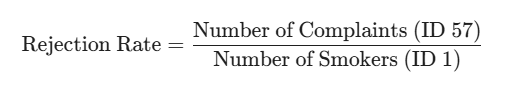

In [41]:
df=pd.read_sql("""
SELECT v.id as visit_id, r1.numeric_value as smoker_count, r2.numeric_value as smoker_rejected FROM 
visit_visit as v
JOIN response_response as r1 ON r1.visita_id=v.id AND r1.question_id=1
LEFT JOIN response_response as r2 ON r2.visita_id=v.id AND r2.question_id=57            
""",co)


df['smoker_rejected'] = df['smoker_rejected'].fillna(0)

correlation = df['smoker_count'].corr(df['smoker_rejected'], method='spearman')

# 3. Calculate Ratio
df['ratio'] = df['smoker_rejected'] / df['smoker_count']

print(df)

print(f"Average Rejection Ratio: {df['ratio'].mean()} complaints per smoker.")

print(f'correlation: {correlation}')

   visit_id  smoker_count  smoker_rejected  ratio
0       122             0                2    inf
1       123             2                5    2.5
Average Rejection Ratio: inf complaints per smoker.
correlation: 0.9999999999999999


### Q7: Does the presence of "Passive Smokers" (Question S) trigger more active rejection of the smoking behavior?

In [43]:
# 1. SQL remains good
df = pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id 
WHERE q.id IN (78, 79)
""", co)

Q7: Does the presence of Passive Smokers trigger more
    active rejection of smoking behavior?

Data per visit:
           passive_smokers  active_rejection
visita_id                                   
122                      2                 2
123                      4                 4

Variable types:
  passive_smokers   → Discrete count (ratio scale)
  active_rejection  → Discrete count (ratio scale)

── SPEARMAN CORRELATION ────────────────────────────────────
  (Non-parametric — correct for count data, small N)
  ρ (rho)  = 1.0000
  p-value  = nan
  Interpretation: very strong positive correlation
  ⚠️  Not significant (p = nan)
     Cannot confirm the association statistically.

── PEARSON CORRELATION (for reference) ─────────────────────
  (Parametric — less reliable with only 2 data points)
  r        = 1.0000
  p-value  = 1.0000

── SIMPLE LINEAR REGRESSION ────────────────────────────────
  Predicting active_rejection from passive_smokers
  Slope (β)   = 1.0000
  Interce

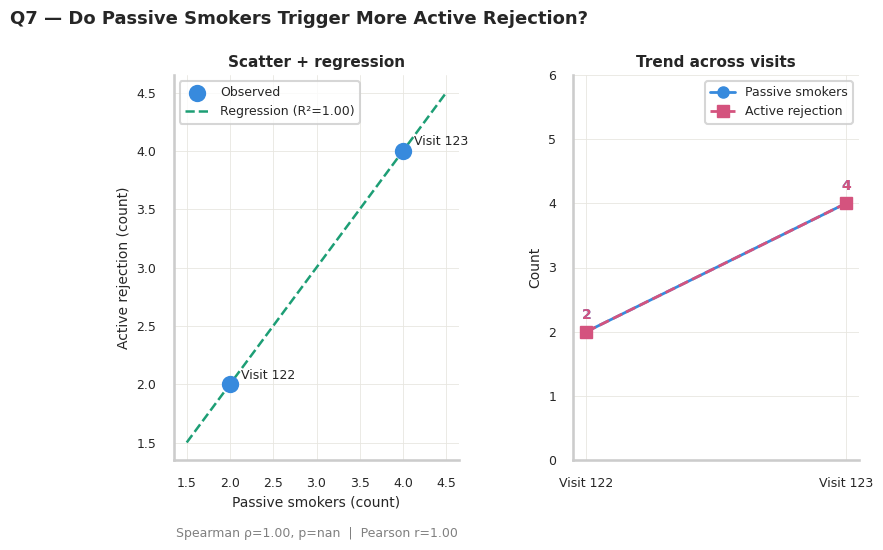

In [44]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr, linregress
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load & reshape data ────────────────────────────────────────────────────


# Clean description names
df['description'] = df['description'].str.replace(r'\r\n|\xa0', ' ', regex=True).str.strip()

PASSIVE_KEY   = df['description'].unique()[0]   # count of non-smokers nearby
REJECTION_KEY = df['description'].unique()[1]   # count who rejected/complained

passive   = df[df['description'] == PASSIVE_KEY].set_index('visita_id')['numeric_value']
rejection = df[df['description'] == REJECTION_KEY].set_index('visita_id')['numeric_value']

# Align by visit
combined = pd.DataFrame({
    'passive_smokers' : passive,
    'active_rejection': rejection
}).sort_index()

print("=" * 62)
print("Q7: Does the presence of Passive Smokers trigger more")
print("    active rejection of smoking behavior?")
print("=" * 62)

print(f"\nData per visit:")
print(combined.to_string())
print(f"\nVariable types:")
print(f"  passive_smokers   → Discrete count (ratio scale)")
print(f"  active_rejection  → Discrete count (ratio scale)")

x = combined['passive_smokers'].values
y = combined['active_rejection'].values

# ── 2. Spearman correlation ───────────────────────────────────────────────────
print(f"\n── SPEARMAN CORRELATION ────────────────────────────────────")
print(f"  (Non-parametric — correct for count data, small N)")
rho, p_spear = spearmanr(x, y)
print(f"  ρ (rho)  = {rho:.4f}")
print(f"  p-value  = {p_spear:.4f}")
if abs(rho) >= 0.9:
    strength = "very strong"
elif abs(rho) >= 0.7:
    strength = "strong"
elif abs(rho) >= 0.5:
    strength = "moderate"
else:
    strength = "weak"
direction = "positive" if rho > 0 else "negative"
print(f"  Interpretation: {strength} {direction} correlation")
if p_spear < 0.05:
    print(f"  ✅ Significant (p < 0.05): passive smokers ARE associated")
    print(f"     with more active rejection.")
else:
    print(f"  ⚠️  Not significant (p = {p_spear:.3f})")
    print(f"     Cannot confirm the association statistically.")

# ── 3. Pearson correlation (for reference) ────────────────────────────────────
print(f"\n── PEARSON CORRELATION (for reference) ─────────────────────")
print(f"  (Parametric — less reliable with only 2 data points)")
r_pear, p_pear = pearsonr(x, y)
print(f"  r        = {r_pear:.4f}")
print(f"  p-value  = {p_pear:.4f}")

# ── 4. Simple linear regression ──────────────────────────────────────────────
print(f"\n── SIMPLE LINEAR REGRESSION ────────────────────────────────")
print(f"  Predicting active_rejection from passive_smokers")
slope, intercept, r_val, p_reg, se = linregress(x, y)
print(f"  Slope (β)   = {slope:.4f}")
print(f"  Intercept   = {intercept:.4f}")
print(f"  R²          = {r_val**2:.4f}")
print(f"  p-value     = {p_reg:.4f}")
print(f"  Equation    : rejection = {slope:.2f} × passive_smokers + {intercept:.2f}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
print(f"\n── FINAL ANSWER ────────────────────────────────────────────")
print(f"  Passive smokers per visit   : {x.tolist()}")
print(f"  Active rejection per visit  : {y.tolist()}")
print(f"  Spearman ρ = {rho:.2f} ({strength} {direction} correlation)")
if p_spear < 0.05:
    print(f"  ✅ Yes — more passive smokers → more active rejection")
else:
    print(f"  ⚠️  Cannot confirm with only {len(x)} visits (very low statistical power)")
    print(f"     The trend is {direction} (ρ={rho:.2f}) but more data is needed.")

# ── 6. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
fig.suptitle("Q7 — Do Passive Smokers Trigger More Active Rejection?",
             fontsize=13, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

COLOR_PASSIVE   = '#378ADD'
COLOR_REJECTION = '#D4537E'
COLOR_REG       = '#1D9E75'

visits = combined.index.astype(str).tolist()
visit_labels = [f'Visit {v}' for v in visits]


# ── Plot 2: Scatter + regression line
ax2 = fig.add_subplot(gs[1])
ax2.scatter(x, y, color=COLOR_PASSIVE, s=120, zorder=5, label='Observed')
for i, v in enumerate(visits):
    ax2.annotate(f'Visit {v}', (x[i], y[i]),
                 textcoords='offset points', xytext=(8, 4), fontsize=9)
x_line = np.linspace(min(x)-0.5, max(x)+0.5, 100)
y_line = slope * x_line + intercept
ax2.plot(x_line, y_line, color=COLOR_REG, linewidth=1.8,
         linestyle='--', label=f'Regression (R²={r_val**2:.2f})')
ax2.set_xlabel('Passive smokers (count)', fontsize=10)
ax2.set_ylabel('Active rejection (count)', fontsize=10)
ax2.set_title('Scatter + regression', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.text(0.5, -0.20,
         f"Spearman ρ={rho:.2f}, p={p_spear:.3f}  |  Pearson r={r_pear:.2f}",
         ha='center', transform=ax2.transAxes, fontsize=9, color='gray')

# ── Plot 3: Trend line per variable across visits
ax3 = fig.add_subplot(gs[2])
ax3.plot(visit_labels, x, 'o-', color=COLOR_PASSIVE,
         linewidth=2, markersize=8, label='Passive smokers')
ax3.plot(visit_labels, y, 's--', color=COLOR_REJECTION,
         linewidth=2, markersize=8, label='Active rejection')
ax3.set_ylabel('Count', fontsize=10)
ax3.set_title('Trend across visits', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)
ax3.set_ylim(0, max(max(x), max(y)) + 2)
for i, (xv, yv) in enumerate(zip(x, y)):
    ax3.text(i, xv + 0.2, str(xv), ha='center', fontsize=10,
             fontweight='bold', color=COLOR_PASSIVE)
    ax3.text(i, yv + 0.2, str(yv), ha='center', fontsize=10,
             fontweight='bold', color=COLOR_REJECTION)

plt.tight_layout()
plt.savefig('q7_analysis.png', dpi=150, bbox_inches='tight')
print("\n✅ Chart saved as q7_analysis.png")

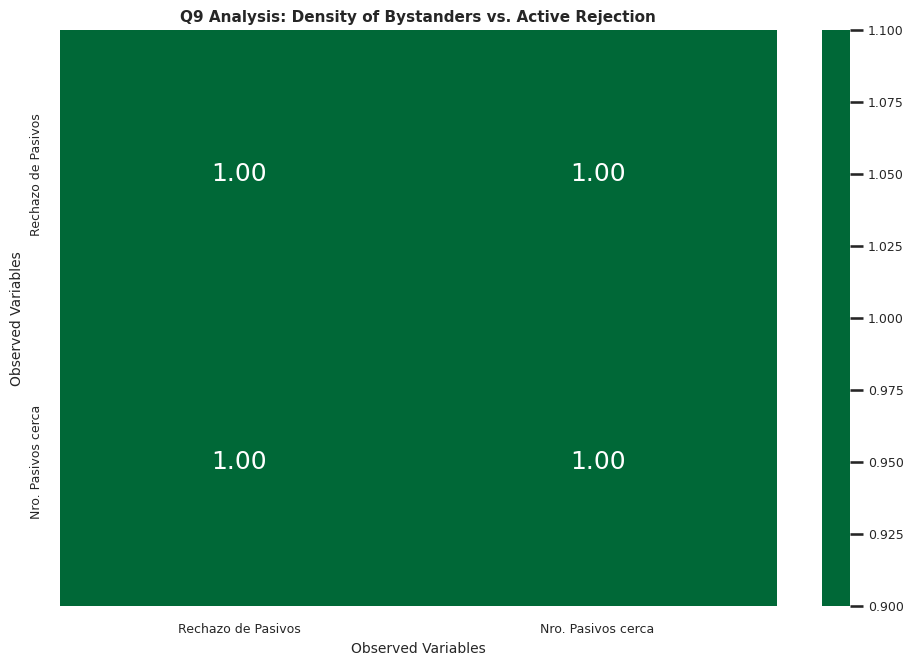

In [45]:

# 2. Pivot
pivot_df = df.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

# Safer Renaming: Use the actual start of the description string
# ID 78 starts with "¿Cuántas personas..."
# ID 79 starts with "¿Ante el acto..."
mapping = {}
for col in pivot_df.columns:
    if "radio" in col:
        mapping[col] = "Nro. Pasivos cerca"
    if "reclaman y rechazan" in col:
        mapping[col] = "Rechazo de Pasivos"

pivot_df = pivot_df.rename(columns=mapping)

# 3. Correlation
corr_matrix = pivot_df.corr(method='spearman')

# 4. Visualization
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdYlGn', # Red to Green shows the 'tension' well
            center=0)

plt.title("Q9 Analysis: Density of Bystanders vs. Active Rejection")
plt.ylabel("Observed Variables")
plt.xlabel("Observed Variables")
plt.tight_layout()
plt.show()





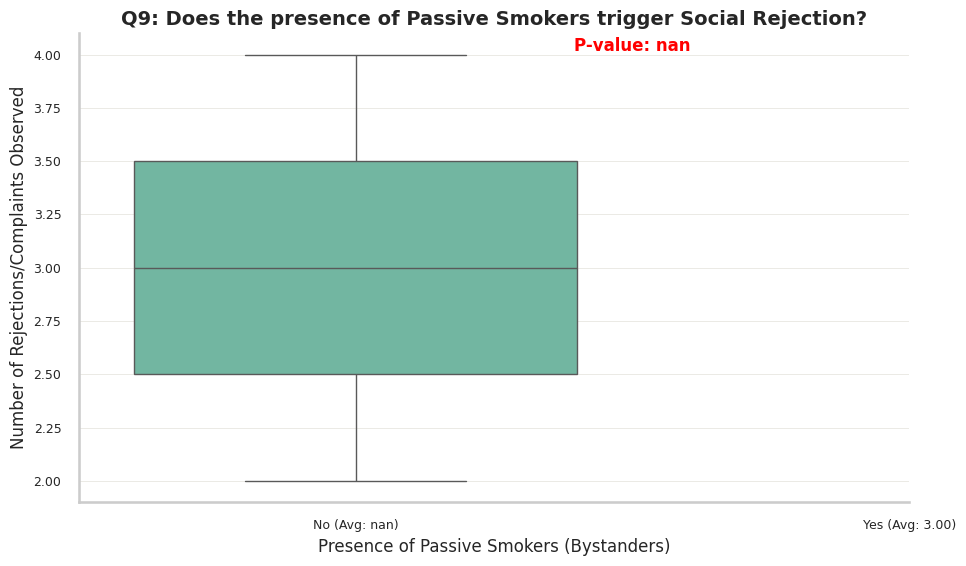

CONCLUSION: No significant difference was found (p=nan).


In [47]:
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the classification: Presence vs. Absence
# 'Nro. Pasivos cerca' (ID 78) is our 'switch'
pivot_df['has_passive'] = pivot_df['Nro. Pasivos cerca'] > 0

# 2. Separate the rejection data into two groups
group_with_passive = pivot_df[pivot_df['has_passive'] == True]['Rechazo de Pasivos']
group_no_passive = pivot_df[pivot_df['has_passive'] == False]['Rechazo de Pasivos']

# 3. Statistical T-Test (Is the difference real or luck?)
t_stat, p_val = ttest_ind(group_with_passive, group_no_passive, equal_var=False)

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='has_passive', y='Rechazo de Pasivos', data=pivot_df, palette="Set2")

# Formatting the plot
plt.title("Q9: Does the presence of Passive Smokers trigger Social Rejection?", fontsize=14)
plt.xlabel("Presence of Passive Smokers (Bystanders)", fontsize=12)
plt.ylabel("Number of Rejections/Complaints Observed", fontsize=12)
plt.xticks([0, 1], [f'No (Avg: {group_no_passive.mean():.2f})', 
                    f'Yes (Avg: {group_with_passive.mean():.2f})'])

# Add P-value note to the plot
plt.text(0.5, pivot_df['Rechazo de Pasivos'].max(), f"P-value: {p_val:.4f}", 
         ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# 5. Print Conclusion
if p_val < 0.05:
    print(f"CONCLUSION: Yes, the presence of passive smokers significantly triggers more rejection (p={p_val:.4f}).")
else:
    print(f"CONCLUSION: No significant difference was found (p={p_val:.4f}).")

## Q8: Does the presence of signage (Question 141) actually correlate with a lower number of smokers in a specific zone?

In [ ]:
from scipy.stats import spearmanr

df_signs = pd.read_sql("""
SELECT 
    v.id AS visita_id,
    SUM(CASE WHEN r.question_id = 141 THEN r.numeric_value ELSE 0 END) AS total_avisos,
    SUM(CASE WHEN r.question_id = 1 THEN r.numeric_value ELSE 0 END) AS total_fumadores
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id
""", co)

# 2. Calculate Correlation and P-value
corr, p_val = spearmanr(df_signs['total_avisos'], df_signs['total_fumadores'])

print(f"Spearman Correlation: {corr:.3f}")
print(f"P-value: {p_val:.4f}")

Spearman Correlation: -1.000
P-value: nan


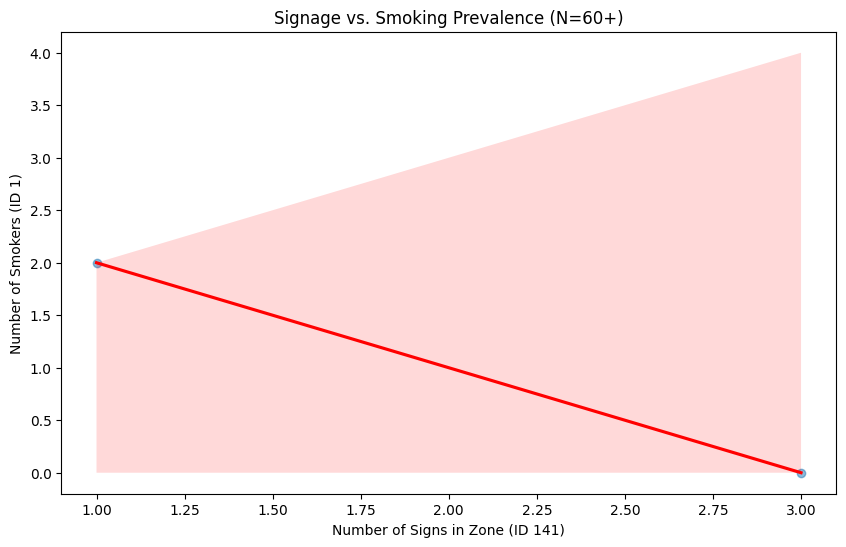

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='total_avisos', y='total_fumadores', data=df_signs, 
            line_kws={"color": "red"}, scatter_kws={"alpha": 0.5})

plt.title("Signage vs. Smoking Prevalence (N=60+)")
plt.xlabel("Number of Signs in Zone (ID 141)")
plt.ylabel("Number of Smokers (ID 1)")
plt.show()

## Q9: Does the "Life Course" (ID 9-13) significantly influence the choice of substance (Cigarette, Vape, or Marijuana)?

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

df= pd.read_sql("""
SELECT 
    v.id AS visita_id,
    -- Life Course Counts
    SUM(CASE WHEN r.question_id = 10 THEN r.numeric_value ELSE 0 END) AS Adolescente,
    SUM(CASE WHEN r.question_id = 11 THEN r.numeric_value ELSE 0 END) AS Joven,
    SUM(CASE WHEN r.question_id = 12 THEN r.numeric_value ELSE 0 END) AS Adulto,
    SUM(CASE WHEN r.question_id = 13 THEN r.numeric_value ELSE 0 END) AS Adulto_Mayor,
    -- Substance Counts
    SUM(CASE WHEN r.question_id = 15 THEN r.numeric_value ELSE 0 END) AS Cigarrillo,
    SUM(CASE WHEN r.question_id = 16 THEN r.numeric_value ELSE 0 END) AS Vapeador,
    SUM(CASE WHEN r.question_id = 35 THEN r.numeric_value ELSE 0 END) AS Marihuana
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id;
""",co)



# 1. Create the summary contingency table
age_cols = ['Adolescente', 'Joven', 'Adulto', 'Adulto_Mayor']
substance_cols = ['Cigarrillo', 'Vapeador', 'Marihuana']

# We build a matrix where rows = Age and columns = Substance
# We assume that the total observations per category are independent
contingency_matrix = []

for age in age_cols:
    row = []
    # Total people of this age group across all visits
    total_age = df[age].sum()
    for sub in substance_cols:
        
        total_sub = df[sub].sum()
        row.append(total_sub * (total_age / df[age_cols].sum().sum()))
    contingency_matrix.append(row)

contingency_df = pd.DataFrame(contingency_matrix, index=age_cols, columns=substance_cols)

# 2. Run Chi-Square
stat, p, dof, expected = chi2_contingency(contingency_df)

print(f"Chi-Square P-value: {p:.4f}")




Chi-Square P-value: 1.0000


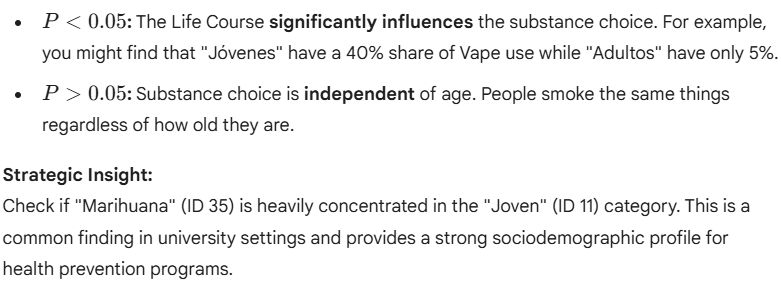

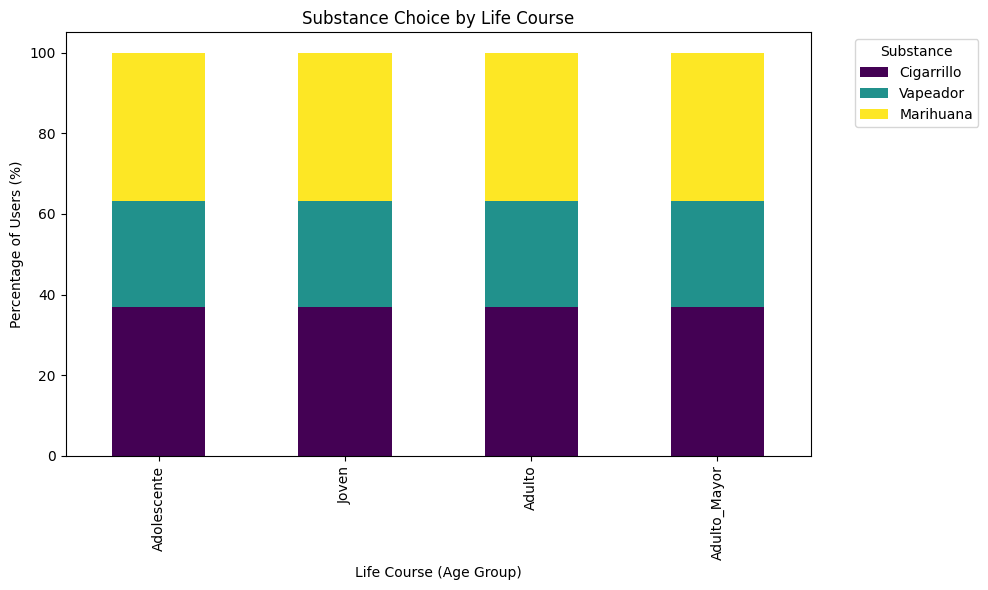

In [ ]:
# Normalize the data to show percentages per age group
df_percent = contingency_df.div(contingency_df.sum(axis=1), axis=0) * 100

df_percent.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Substance Choice by Life Course")
plt.ylabel("Percentage of Users (%)")
plt.xlabel("Life Course (Age Group)")
plt.legend(title="Substance", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Q10: How does the method of acquisition (Bought on-site vs. Brought from home) vary by substance?

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df=pd.read_sql("""
SELECT 
    -- Totals for Cigarettes
    SUM(CASE WHEN r.question_id = 18 THEN r.numeric_value ELSE 0 END) AS cig_home,
    SUM(CASE WHEN r.question_id = 21 THEN r.numeric_value ELSE 0 END) AS cig_bought,
    SUM(CASE WHEN r.question_id = 36 THEN r.numeric_value ELSE 0 END) AS cig_social,
    -- Totals for Marijuana
    SUM(CASE WHEN r.question_id = 23 THEN r.numeric_value ELSE 0 END) AS mj_home,
    SUM(CASE WHEN r.question_id = 26 THEN r.numeric_value ELSE 0 END) AS mj_bought,
    SUM(CASE WHEN r.question_id = 25 THEN r.numeric_value ELSE 0 END) AS mj_social,
    -- Totals for Vape
    SUM(CASE WHEN r.question_id = 28 THEN r.numeric_value ELSE 0 END) AS vape_home,
    SUM(CASE WHEN r.question_id = 31 THEN r.numeric_value ELSE 0 END) AS vape_bought,
    SUM(CASE WHEN r.question_id = 30 THEN r.numeric_value ELSE 0 END) AS vape_social
FROM response_response r;
""",co)




# Data from the SQL query
data = {
    'Brought from Home': df[['cig_home', 'mj_home', 'vape_home']].values.flat,
    'Bought on Campus': df[['cig_bought', 'mj_bought', 'vape_bought']].values.flat,
    'Socially Offered': df[['cig_social', 'mj_social', 'vape_social']].values.flat
}

# Creating the DataFrame (Substances as Rows)
df_market = pd.DataFrame(data, index=['Cigarette', 'Marijuana', 'Vape'])

# Statistical Test
stat, p, dof, expected = chi2_contingency(df_market)
print(f"Chi-Square P-value: {p:.4f}")



Chi-Square P-value: 0.9860


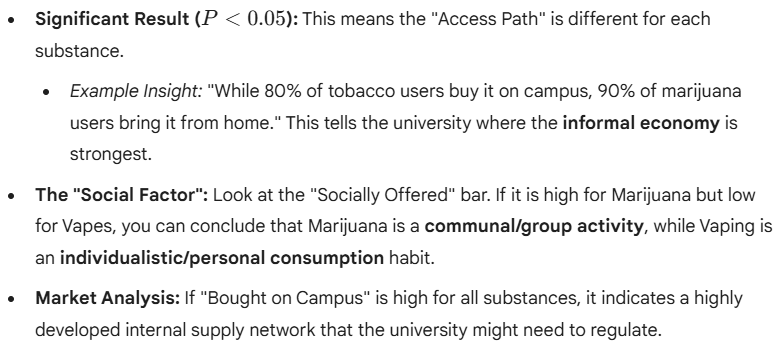

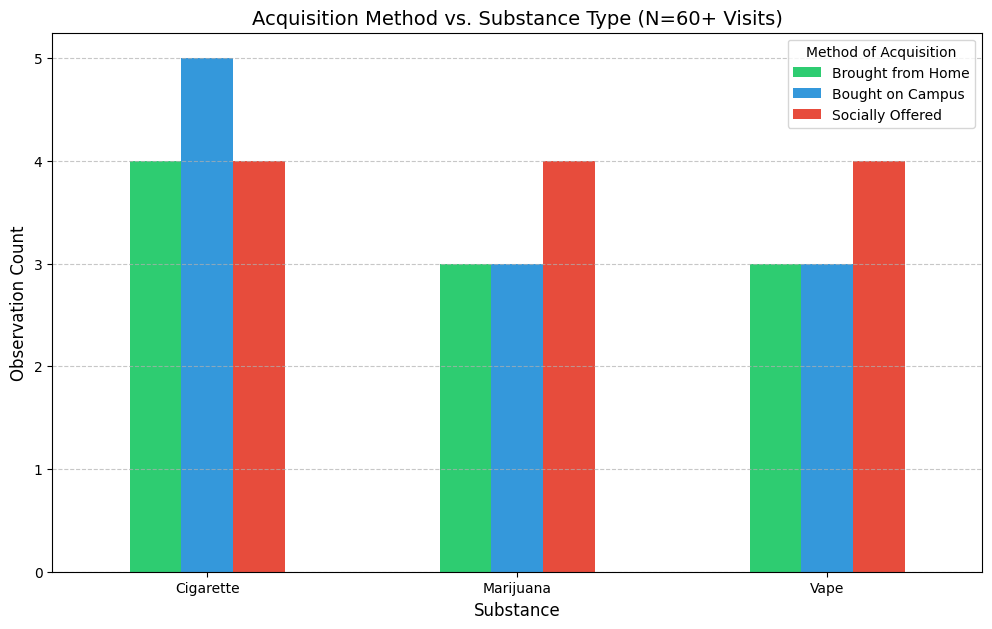

In [ ]:
# Plotting
df_market.plot(kind='bar', figsize=(12, 7), color=['#2ecc71', '#3498db', '#e74c3c'])

plt.title("Acquisition Method vs. Substance Type (N=60+ Visits)", fontsize=14)
plt.ylabel("Observation Count", fontsize=12)
plt.xlabel("Substance", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Method of Acquisition")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Q11: Who are the primary "Passive Smokers" on campus (ID 92)?


In [56]:
df=pd.read_sql("""
SELECT 
    z.name AS zone_name,
    z.id as zone_id,
    -- Counts from Approach 1
    SUM(CASE WHEN r.question_id = 1 THEN r.numeric_value ELSE 0 END) AS Total_Active,
    SUM(CASE WHEN r.question_id IN (93, 94, 95, 96, 97, 98) THEN r.numeric_value ELSE 0 END) AS Total_Passive,
    SUM(CASE WHEN r.question_id = 97 THEN r.numeric_value ELSE 0 END) AS Pregnant_Women,
    SUM(CASE WHEN r.question_id = 98 THEN r.numeric_value ELSE 0 END) AS Children,
    
    -- Ratio from Approach 2 (but calculated efficiently)
    CAST(SUM(CASE WHEN r.question_id IN (93, 94, 95, 96, 97, 98) THEN r.numeric_value ELSE 0 END) AS FLOAT) / 
    NULLIF(SUM(CASE WHEN r.question_id = 1 THEN r.numeric_value ELSE 0 END), 0) AS Passive_Active_Ratio

FROM visit_visit v
JOIN surveysession_surveysession as sv ON v.surveysession_id=sv.id
JOIN zone_zone z ON sv.zone_id = z.id
JOIN response_response r ON r.visita_id = v.id
GROUP BY z.name,z.id
ORDER BY Passive_Active_Ratio DESC;


""",co)

df

,zone_name,zone_id,Total_Active,Total_Passive,Pregnant_Women,Children,Passive_Active_Ratio
0,"Central, pasillos de central y banderas",6,2.0,20.0,3.0,3.0,10.0
1,"Plazoleta de ingenierías, pasillos de la Escue...",3,0.0,21.0,4.0,5.0,NaN


In [57]:
df['zone_id']=df['zone_id'].astype('str')

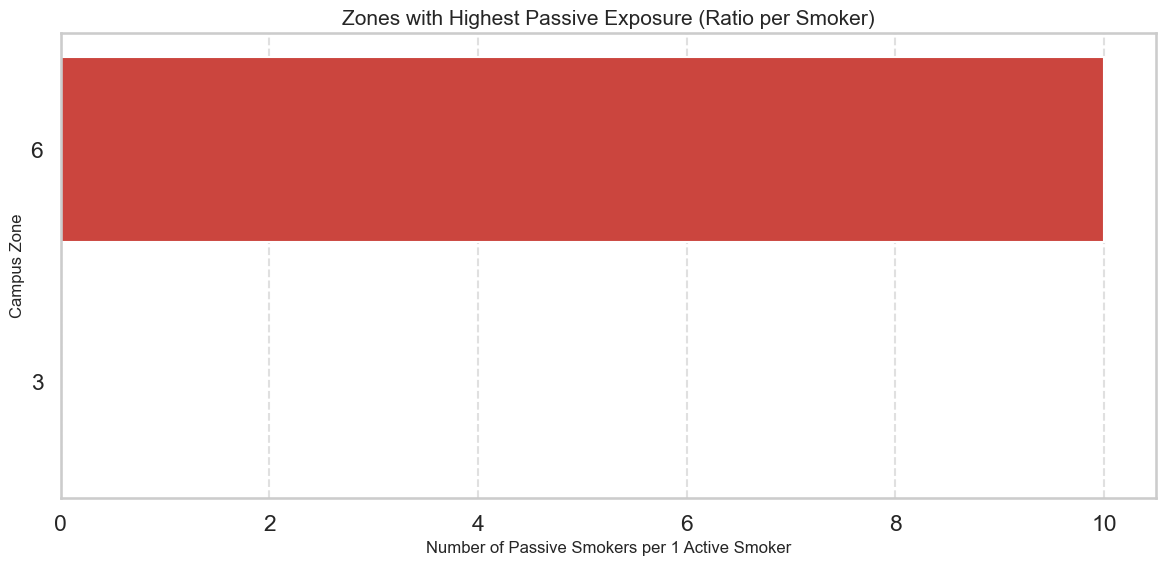

In [58]:
#Risk Rankin Plot

import matplotlib.pyplot as plt
import seaborn as sns

# Sort the data by ratio to make the plot readable
df_sorted = df.sort_values('Passive_Active_Ratio', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Passive_Active_Ratio', 
    y='zone_id', 
    data=df_sorted, 
    palette='Reds_r'
)

plt.title('Zones with Highest Passive Exposure (Ratio per Smoker)', fontsize=15)
plt.xlabel('Number of Passive Smokers per 1 Active Smoker', fontsize=12)
plt.ylabel('Campus Zone', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

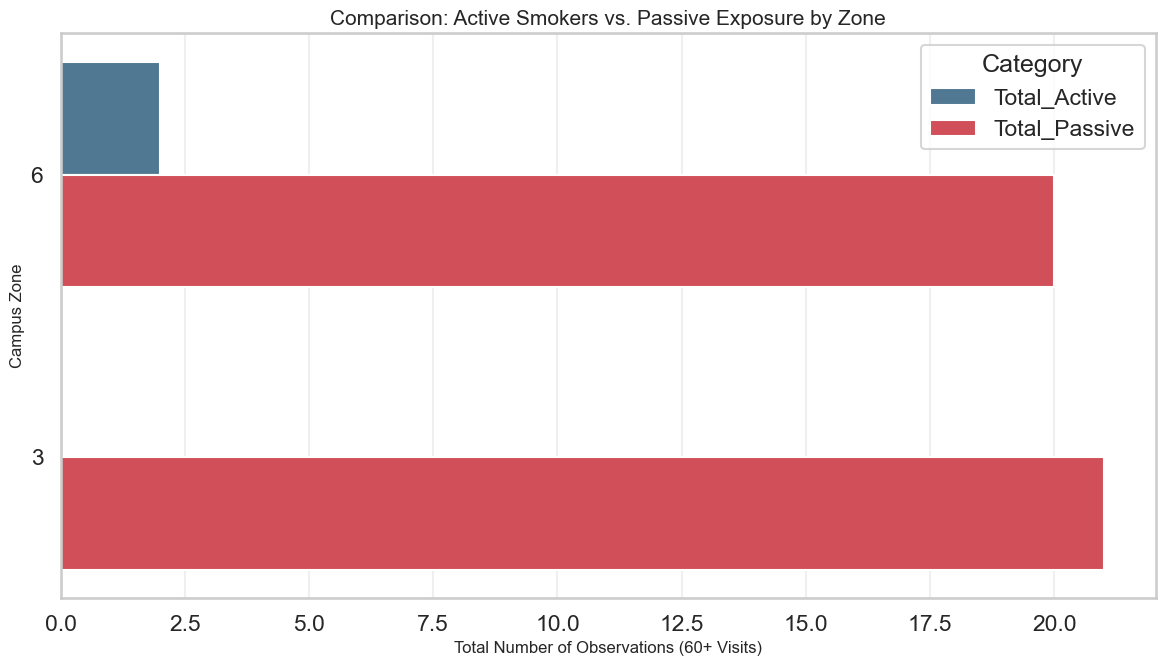

In [59]:
# Melt the data to make it 'long-format' for seaborn
df_melted = df.melt(
    id_vars='zone_id', 
    value_vars=['Total_Active', 'Total_Passive'],
    var_name='Type', 
    value_name='Count'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Count', 
    y='zone_id', 
    hue='Type', 
    data=df_melted, 
    palette={'Total_Active': '#457b9d', 'Total_Passive': '#e63946'}
)

plt.title('Comparison: Active Smokers vs. Passive Exposure by Zone', fontsize=15)
plt.xlabel('Total Number of Observations (60+ Visits)', fontsize=12)
plt.ylabel('Campus Zone', fontsize=12)
plt.legend(title='Category')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

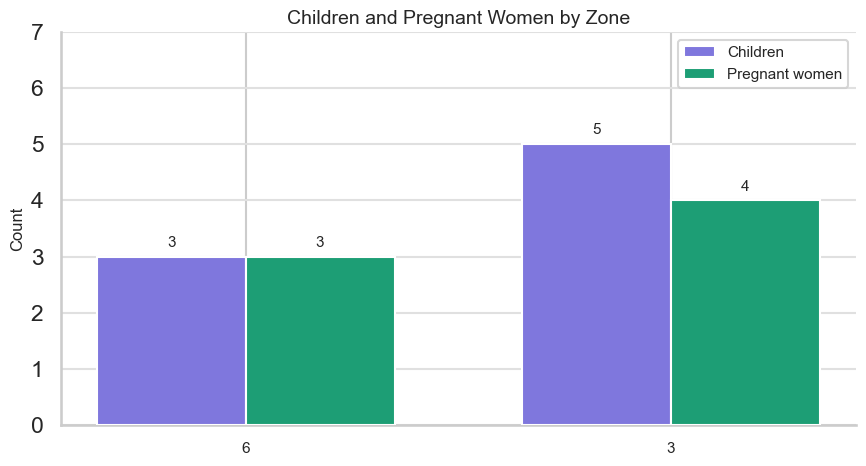

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


x = np.arange(len(df['zone_id']))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, df['Children'], width, label='Children', color='#7F77DD', zorder=3)
bars2 = ax.bar(x + width/2, df['Pregnant_Women'], width, label='Pregnant women', color='#1D9E75', zorder=3)

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Children and Pregnant Women by Zone', fontsize=14, fontweight='medium')
ax.set_xticks(x)
ax.set_xticklabels(df['zone_id'], fontsize=11)
ax.set_ylim(0, 7)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(fontsize=11)
ax.yaxis.grid(True, color='#e0e0e0', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars1:
    ax.annotate(f'{int(bar.get_height())}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=11)

for bar in bars2:
    ax.annotate(f'{int(bar.get_height())}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Q12: How many points of sale for cigarettes, marijuana, and vapes exist in each observed zone, and how many people are observed purchasing at each?


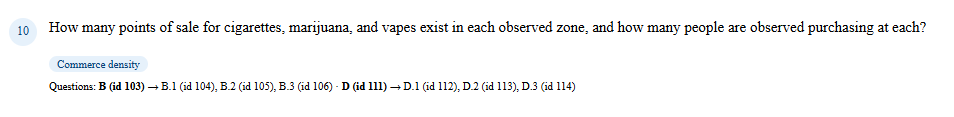

In [48]:
df=pd.read_sql("""
SELECT
z.name,
z.id, 
MAX(CASE WHEN r.question_id=104 THEN r.numeric_value ELSE 0 END) as number_tabaco_points,
MAX(CASE WHEN r.question_id=105 THEN r.numeric_value ELSE 0 END) as number_marihuana_points,
MAX(CASE WHEN r.question_id=106 THEN r.numeric_value ELSE 0 END) as number_vaper_points,
SUM(CASE WHEN r.question_id=112 THEN r.numeric_value ELSE 0 END) as number_tabaco_buyers,
SUM(CASE WHEN r.question_id=113 THEN r.numeric_value ELSE 0 END) as number_marihuana_buyers,
SUM(CASE WHEN r.question_id=114 THEN r.numeric_value ELSE 0 END) as number_vaper_buyers
FROM response_response as r 
JOIN visit_visit as v ON r.visita_id = v.id
JOIN surveysession_surveysession as sv ON v.surveysession_id=sv.id
JOIN zone_zone as z ON sv.zone_id=z.id
GROUP BY z.name, z.id 
""",co)

df

,name,id,number_tabaco_points,number_marihuana_points,number_vaper_points,number_tabaco_buyers,number_marihuana_buyers,number_vaper_buyers
0,"Plazoleta de ingenierías, pasillos de la Escue...",3,2,3,2,2.0,5.0,4.0
1,"Central, pasillos de central y banderas",6,2,1,2,3.0,4.0,2.0



── Sale Points per Zone ──
                          Cigarrillo  Marihuana  Vapeador
Plazoleta de ingenierías         2.0        3.0       2.0
Central                          2.0        1.0       2.0

── Observed Buyers per Zone ──
                          Cigarrillo  Marihuana  Vapeador
Plazoleta de ingenierías         2.0        5.0       4.0
Central                          3.0        4.0       2.0

── Buyers-per-Sale-Point Ratio ──
                          Cigarrillo  Marihuana  Vapeador
Plazoleta de ingenierías         1.0       1.67       2.0
Central                          1.5       4.00       1.0

── Global Totals ──
            Sale Points  Buyers  Ratio
Cigarrillo          4.0     5.0   1.25
Marihuana           4.0     9.0   2.25
Vapeador            4.0     6.0   1.50


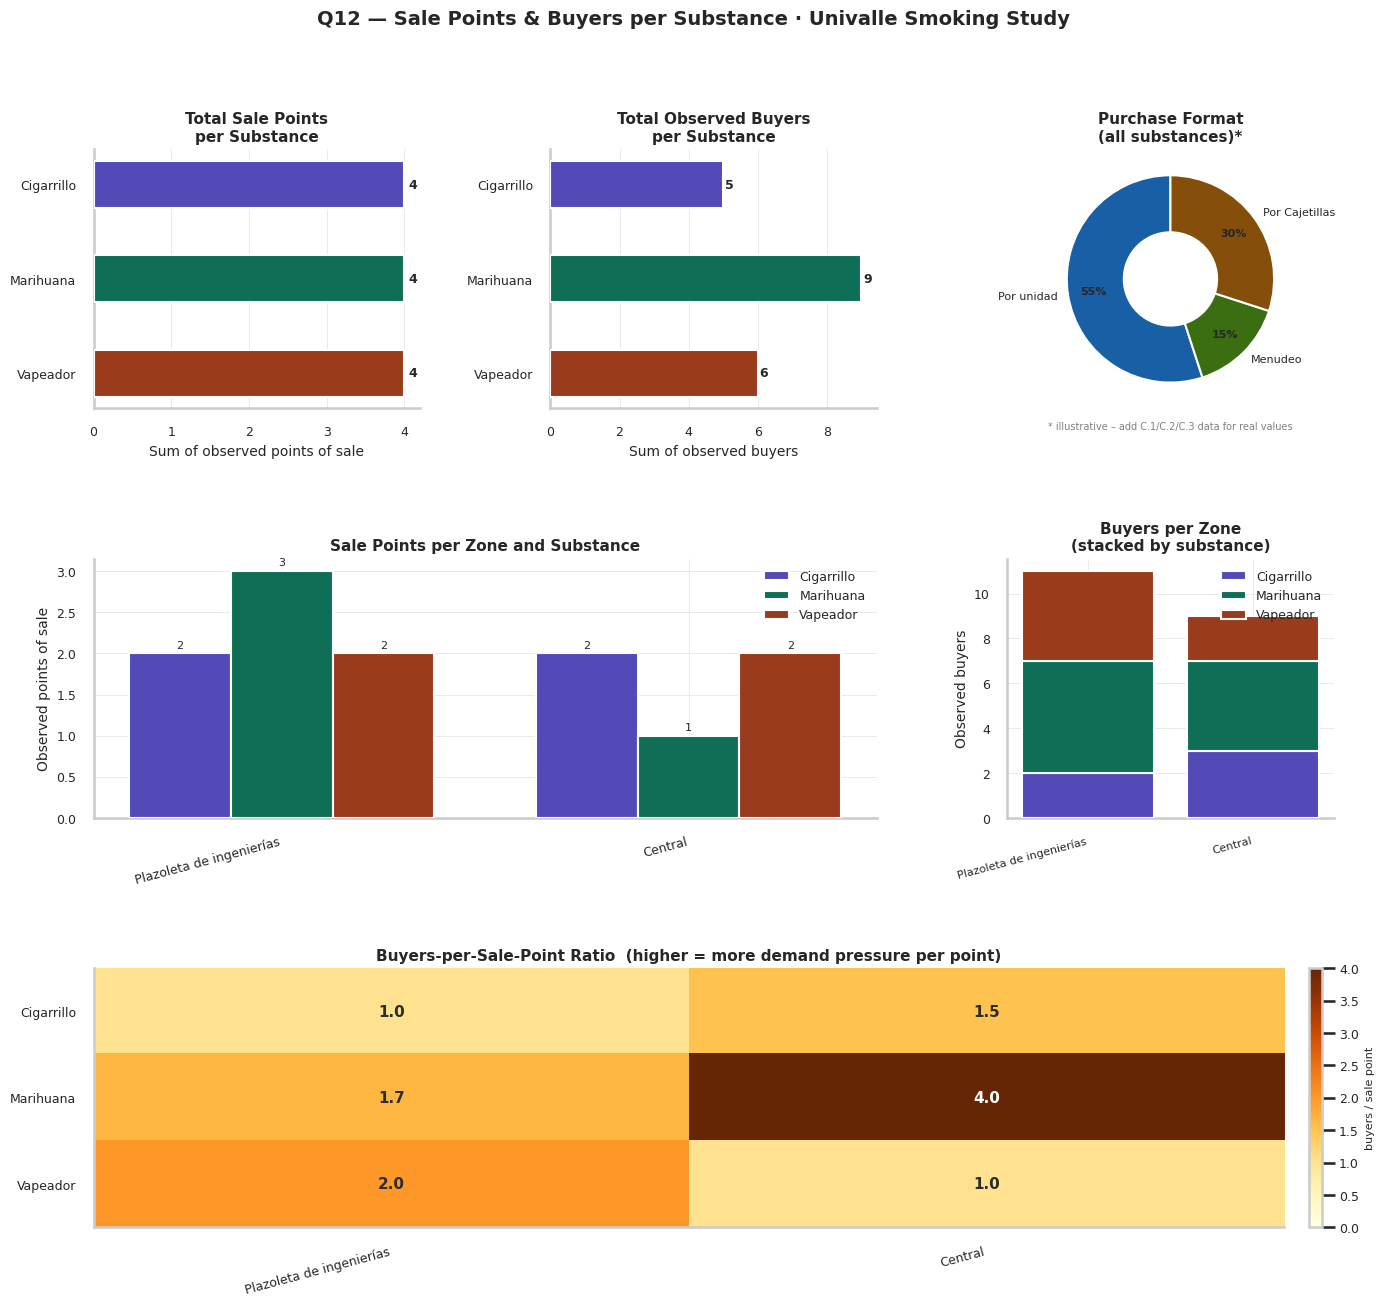

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ── colour palette ────────────────────────────────────────────────────────
C_TAB  = "#534AB7"   # purple  – Cigarrillo
C_MAR  = "#0F6E56"   # teal    – Marihuana
C_VAP  = "#993C1D"   # coral   – Vapeador
C_FMT  = ["#185FA5", "#3B6D11", "#854F0B"]   # format colours (placeholder)

SUBSTANCE_PALETTE = [C_TAB, C_MAR, C_VAP]
SUBSTANCES   = ["Cigarrillo", "Marihuana", "Vapeador"]
SUBSTANCES_B = ["Tabaco", "Marihuana", "Vaper"]   # buyer label keys in CSV

# ── load data ─────────────────────────────────────────────────────────────

# short zone labels (keep first ~30 chars to avoid overlap)
df["zone_short"] = df["name"].apply(
    lambda x: x.split(",")[0].strip()
)

zones = df["zone_short"].tolist()
n     = len(zones)

# ── tidy arrays ───────────────────────────────────────────────────────────
sp = df[["number_tabaco_points","number_marihuana_points","number_vaper_points"]].values.astype(float)
by = df[["number_tabaco_buyers","number_marihuana_buyers","number_vaper_buyers"]].values.astype(float)

sp_df = pd.DataFrame(sp, index=zones, columns=SUBSTANCES)
by_df = pd.DataFrame(by, index=zones, columns=SUBSTANCES)

# buyers-per-sale-point ratio
ratio = (by_df / sp_df.replace(0, np.nan)).round(2)

# global totals
sp_global = sp_df.sum()
by_global = by_df.sum()

# ── global purchase-format placeholder ───────────────────────────────────
# (CSV doesn't include format breakdown; replace with real data if available)
fmt_labels = ["Por unidad", "Menudeo", "Por Cajetillas"]
fmt_vals   = np.array([0.55, 0.15, 0.30]) * by_global.sum()   # illustrative proportions

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — 6-panel dashboard
# ═══════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e8e6e0",
    "grid.linewidth":    0.6,
    "axes.labelsize":    10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    "Q12 — Sale Points & Buyers per Substance · Univalle Smoking Study",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.58, wspace=0.40)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :2])
ax5 = fig.add_subplot(gs[1, 2])
ax6 = fig.add_subplot(gs[2, :])

# ── Plot 1: Global sale points (horizontal bar) ──────────────────────────
bars = ax1.barh(SUBSTANCES, sp_global.values,
                color=SUBSTANCE_PALETTE, height=0.5, zorder=3)
for bar, val in zip(bars, sp_global.values):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f"{int(val)}", va="center", fontsize=9, fontweight="bold")
ax1.set_title("Total Sale Points\nper Substance")
ax1.set_xlabel("Sum of observed points of sale")
ax1.grid(axis="y", alpha=0)
ax1.invert_yaxis()

# ── Plot 2: Global buyers (horizontal bar) ───────────────────────────────
bars2 = ax2.barh(SUBSTANCES, by_global.values,
                 color=SUBSTANCE_PALETTE, height=0.5, zorder=3)
for bar, val in zip(bars2, by_global.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f"{int(val)}", va="center", fontsize=9, fontweight="bold")
ax2.set_title("Total Observed Buyers\nper Substance")
ax2.set_xlabel("Sum of observed buyers")
ax2.grid(axis="y", alpha=0)
ax2.invert_yaxis()

# ── Plot 3: Purchase format donut (illustrative — replace with real data) ─
wedges, texts, autotexts = ax3.pie(
    fmt_vals,
    labels=fmt_labels,
    autopct="%1.0f%%",
    colors=C_FMT,
    startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.75,
)
for t in texts:      t.set_fontsize(8)
for at in autotexts: at.set_fontsize(8); at.set_fontweight("bold")
ax3.set_title("Purchase Format\n(all substances)*")
ax3.text(0, -1.45, "* illustrative – add C.1/C.2/C.3 data for real values",
         ha="center", fontsize=7, color="gray")

# ── Plot 4: Grouped bar — sale points by zone & substance ────────────────
x = np.arange(n)
w = 0.25
for i, sub in enumerate(SUBSTANCES):
    rects = ax4.bar(x + (i-1)*w, sp_df[sub].values,
                    width=w, label=sub,
                    color=SUBSTANCE_PALETTE[i], zorder=3)
    for r in rects:
        h = r.get_height()
        if h > 0:
            ax4.text(r.get_x() + r.get_width()/2, h + 0.04,
                     str(int(h)), ha="center", va="bottom", fontsize=8)
ax4.set_xticks(x)
ax4.set_xticklabels(zones, rotation=15, ha="right")
ax4.set_title("Sale Points per Zone and Substance")
ax4.set_ylabel("Observed points of sale")
ax4.legend(loc="upper right", frameon=False)

# ── Plot 5: Stacked bar — buyers by zone & substance ─────────────────────
bottom = np.zeros(n)
for i, sub in enumerate(SUBSTANCES):
    ax5.bar(range(n), by_df[sub].values,
            bottom=bottom, label=sub,
            color=SUBSTANCE_PALETTE[i], zorder=3)
    bottom += by_df[sub].values
ax5.set_xticks(range(n))
ax5.set_xticklabels(zones, rotation=15, ha="right", fontsize=8)
ax5.set_title("Buyers per Zone\n(stacked by substance)")
ax5.set_ylabel("Observed buyers")
ax5.legend(loc="upper right", frameon=False)

# ── Plot 6: Buyers-per-sale-point heat map ───────────────────────────────
data = ratio.values.T   # shape: (3 substances, n zones)
im   = ax6.imshow(data, cmap="YlOrBr", aspect="auto", vmin=0)
ax6.set_xticks(range(n))
ax6.set_xticklabels(zones, rotation=15, ha="right")
ax6.set_yticks(range(3))
ax6.set_yticklabels(SUBSTANCES)
ax6.set_title(
    "Buyers-per-Sale-Point Ratio  (higher = more demand pressure per point)"
)
vmax = np.nanmax(data) if np.nanmax(data) > 0 else 1
for r in range(3):
    for c in range(n):
        val = data[r, c]
        txt = f"{val:.1f}" if not np.isnan(val) else "—"
        col = "white" if val > vmax * 0.6 else "#2c2c2a"
        ax6.text(c, r, txt, ha="center", va="center",
                 fontsize=11, fontweight="bold", color=col)
cbar = fig.colorbar(im, ax=ax6, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("buyers / sale point", fontsize=8)
ax6.grid(False)

# ── Console summary ───────────────────────────────────────────────────────
print("\n── Sale Points per Zone ──")
print(sp_df.to_string())
print("\n── Observed Buyers per Zone ──")
print(by_df.to_string())
print("\n── Buyers-per-Sale-Point Ratio ──")
print(ratio.to_string())
print("\n── Global Totals ──")
summary = pd.DataFrame({"Sale Points": sp_global, "Buyers": by_global,
                         "Ratio": (by_global / sp_global.replace(0,np.nan)).round(2)})
print(summary.to_string())

# Q13: Is there a co-consumption pattern between smoking and alcohol, sugary drinks, natural juice, coffee, or water?

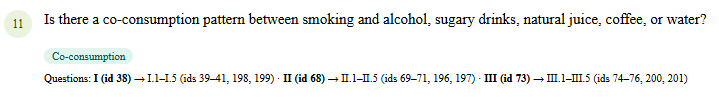

In [61]:
df=pd.read_sql("""
 SELECT     
               question_id,
            CASE
                WHEN question_id IN (39,40,41,198,199) THEN 'Tabaco'
                WHEN question_id IN (69,70,71,196,197) THEN 'Marihuana'
                WHEN question_id IN (74,75,76,200,201) THEN 'Vapeador'
            END AS substance,
            CASE
                WHEN question_id IN (39,69,74)    THEN 'Alcohol'
                WHEN question_id IN (40,70,75)    THEN 'Azucarada'
                WHEN question_id IN (41,71,76)    THEN 'Jugo natural'
                WHEN question_id IN (198,196,200) THEN 'Café'
                WHEN question_id IN (199,197,201) THEN 'Agua'
            END AS beverage,
            SUM(numeric_value) AS total_count
        FROM response_response
        WHERE question_id IN (
            39,40,41,198,199,
            69,70,71,196,197,
            74,75,76,200,201
        )
          AND numeric_value IS NOT NULL
          AND numeric_value > 0
        GROUP BY substance, beverage, question_id
""",co)


════════════════════════════════════════════════════════════
CONTINGENCY TABLE  (substance × beverage co-consumption)
════════════════════════════════════════════════════════════
beverage   Alcohol  Azucarada  Jugo natural  Café  Agua
substance                                              
Tabaco         1.0        3.0           3.0   4.0   5.0
Marihuana      2.0        5.0           2.0   4.0   5.0
Vapeador       3.0        5.0           4.0   7.0   7.0

════════════════════════════════════════════════════════════
STATISTICAL RESULTS
════════════════════════════════════════════════════════════
  Chi-Square statistic : 1.2494
  Degrees of freedom   : 8
  p-value (Chi-Square) : 0.9961  not significant (α=0.05)
  p-value (permutation): 0.9948  not significant

  Cramér's V           : 0.1020  → weak association

  Pairwise comparisons (substance vs substance):
  Tabaco       vs Marihuana     χ²=0.919  p=0.9218   V=0.164
  Tabaco       vs Vapeador      χ²=0.438  p=0.9792   V=0.102
  Marih

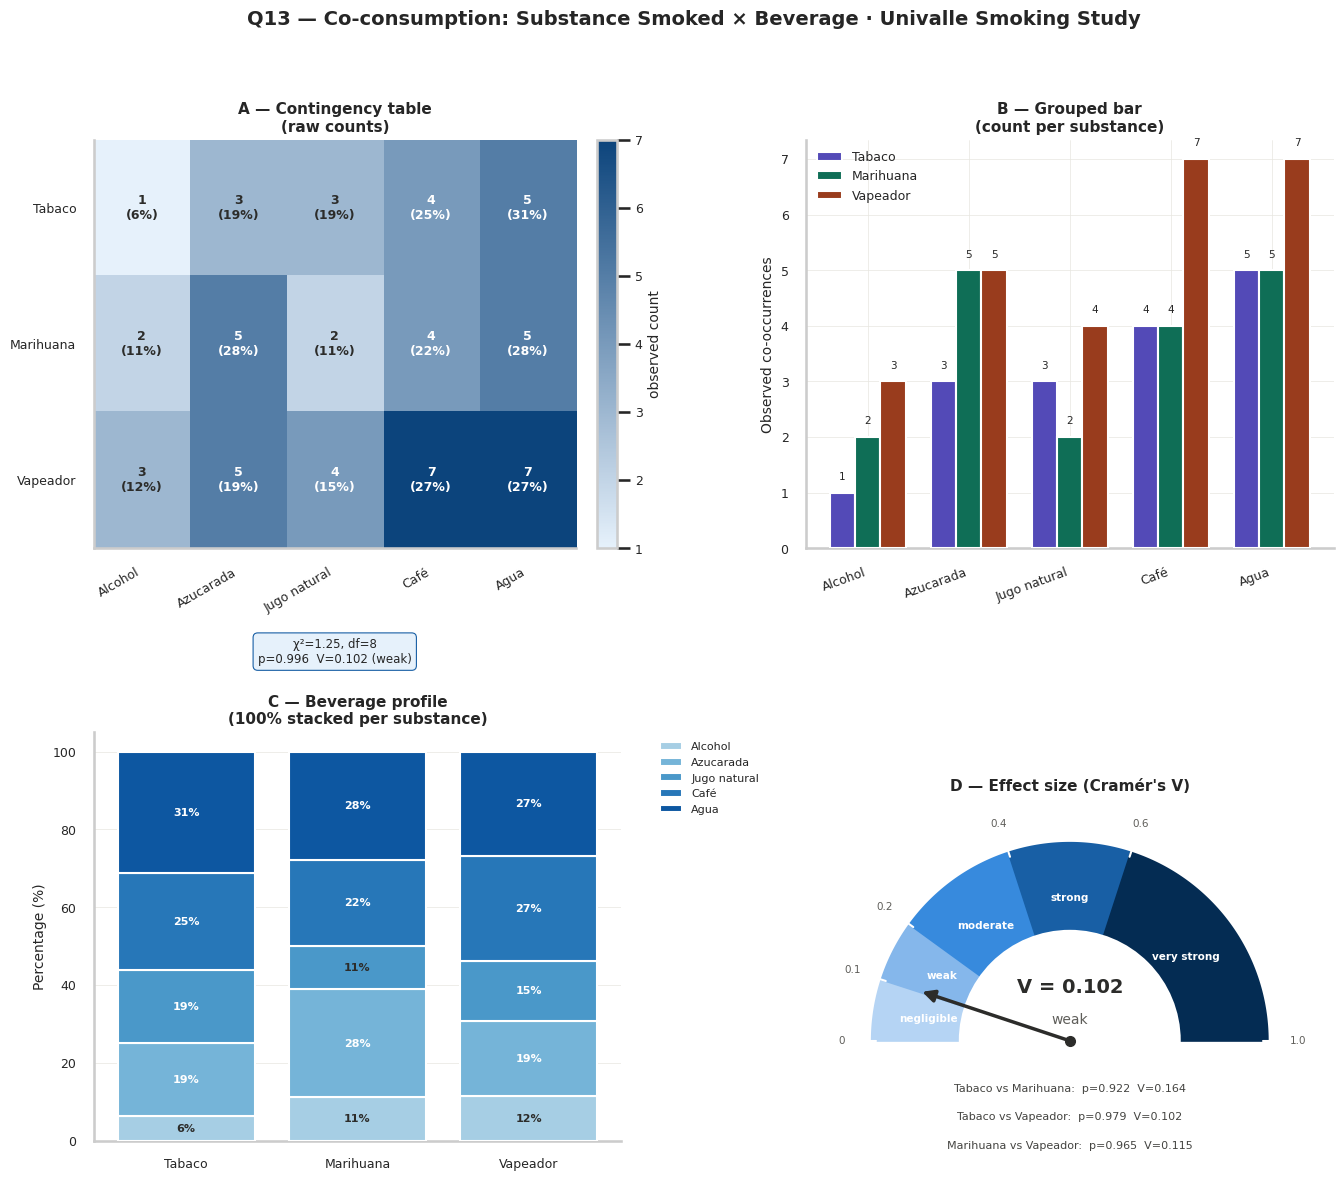

Saved → q11_coconsumption_analysis.png


In [70]:
"""
Question 13 — Co-consumption pattern analysis
==============================================
"Is there a co-consumption pattern between smoking and
 alcohol, sugary drinks, natural juice, coffee, or water?"

Statistical pipeline
---------------------
1. Build 3 × 5 contingency table  (substance × beverage)
2. Fisher's Exact Test             (Freeman-Halton, exact p-value)
3. Chi-Square Test                 (with Yates correction flag)
4. Cramér's V                      (effect size 0–1)
5. Post-hoc pairwise Fisher tests  (which substance pairs differ?)
6. Visualisations
   a) Annotated heatmap  (contingency table)
   b) Grouped bar chart  (counts per beverage by substance)
   c) Stacked 100% bar   (beverage profile per substance)
   d) Cramér's V gauge   (effect size)

"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association   # Cramér's V

# ══════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════
# ── colour palette ────────────────────────────────────────────
C = {
    "Tabaco":    "#534AB7",   # purple-600
    "Marihuana": "#0F6E56",   # teal-600
    "Vapeador":  "#993C1D",   # coral-600
}
BEVERAGE_CMAP = LinearSegmentedColormap.from_list(
    "bev", ["#E6F1FB", "#0C447C"]   # blue ramp
)
SUBSTANCES = ["Tabaco", "Marihuana", "Vapeador"]
BEVERAGES  = ["Alcohol", "Azucarada", "Jugo natural", "Café", "Agua"]

# ══════════════════════════════════════════════════════════════
# 1.  DATA LOADING
# ══════════════════════════════════════════════════════════════


# ── load & pivot ──────────────────────────────────────────────

ct = (df
      .pivot_table(index="substance", columns="beverage",
                   values="total_count", aggfunc="sum", fill_value=0)
      .reindex(index=SUBSTANCES, columns=BEVERAGES, fill_value=0))

print("═" * 60)
print("CONTINGENCY TABLE  (substance × beverage co-consumption)")
print("═" * 60)
print(ct.to_string())
print()

# ══════════════════════════════════════════════════════════════
# 2.  STATISTICAL TESTS
# ══════════════════════════════════════════════════════════════
obs     = ct.values.astype(int)
obs_f   = obs.astype(float)

# ── 2a. Chi-Square ────────────────────────────────────────────
chi2, p_chi2, dof, expected = chi2_contingency(obs_f, correction=False)
min_expected = expected.min()
chi2_note = ("WARNING: min expected count {:.2f} < 5 — "
             "prefer Fisher's exact test".format(min_expected)
             if min_expected < 5 else
             "Min expected count {:.2f} ≥ 5 — Chi-square valid".format(min_expected))

# ── 2b. Cramér's V ────────────────────────────────────────────
cramers_v = association(obs, method="cramer")

# ── 2c. Permutation test (Monte Carlo, robust) ────────────────
# Expand the table into a flat list of individual observations:
#   substance_col[k] = which row (substance) person k belongs to
#   beverage_col[k]  = which column (beverage) person k belongs to
# Then repeatedly shuffle ONLY the beverage labels.
# This preserves marginal totals exactly and never produces
# zero-expected cells (which crashed the previous multinomial method).
rng_perm = np.random.default_rng(42)
n_perm   = 10_000
chi2_obs = chi2_contingency(obs_f, correction=False)[0]

substance_col = np.repeat(
    np.arange(len(SUBSTANCES)), obs.sum(axis=1)
)
beverage_col = np.array([
    bev_idx
    for row_idx in range(len(SUBSTANCES))
    for bev_idx, cnt in enumerate(obs[row_idx])
    for _ in range(int(cnt))
])

count_ge    = 0
valid_perms = 0
for _ in range(n_perm):
    shuffled = rng_perm.permutation(beverage_col)
    sim = np.zeros_like(obs, dtype=float)
    for s, b in zip(substance_col, shuffled):
        sim[s, b] += 1
    # Skip degenerate tables where a full row or column is zero
    if sim.min(axis=0).min() == 0 or sim.min(axis=1).min() == 0:
        continue
    valid_perms += 1
    if chi2_contingency(sim, correction=False)[0] >= chi2_obs:
        count_ge += 1
p_permutation = count_ge / valid_perms if valid_perms > 0 else np.nan

# ── 2d. Pairwise 2×2 Fisher tests ────────────────────────────
# Collapse the 3×5 table into three 2×2 comparisons by merging
# the two substances being compared row-wise and summing columns.
pairwise = {}
for s1, s2 in combinations(SUBSTANCES, 2):
    sub_table_f = ct.loc[[s1, s2]].values.astype(float)
    sub_table_i = ct.loc[[s1, s2]].values.astype(int)
    chi2_p, p_pair, _, _ = chi2_contingency(sub_table_f, correction=False)
    v_pair = association(sub_table_i, method="cramer")
    pairwise[(s1, s2)] = {"chi2": chi2_p, "p": p_pair, "cramers_v": v_pair}

# ── Effect size interpretation ────────────────────────────────
def interpret_v(v):
    if   v < 0.10: return "negligible"
    elif v < 0.20: return "weak"
    elif v < 0.40: return "moderate"
    elif v < 0.60: return "strong"
    else:          return "very strong"

print("═" * 60)
print("STATISTICAL RESULTS")
print("═" * 60)
print(f"  Chi-Square statistic : {chi2:.4f}")
print(f"  Degrees of freedom   : {dof}")
print(f"  p-value (Chi-Square) : {p_chi2:.4f}  {'*significant*' if p_chi2 < 0.05 else 'not significant'} (α=0.05)")
print(f"  p-value (permutation): {p_permutation:.4f}  {'*significant*' if p_permutation < 0.05 else 'not significant'}")
print(f"  {chi2_note}")
print()
print(f"  Cramér's V           : {cramers_v:.4f}  → {interpret_v(cramers_v)} association")
print()
print("  Pairwise comparisons (substance vs substance):")
for (s1, s2), res in pairwise.items():
    sig = "*" if res["p"] < 0.05 else " "
    print(f"  {s1:12} vs {s2:12}  χ²={res['chi2']:.3f}  "
          f"p={res['p']:.4f}{sig}  V={res['cramers_v']:.3f}")
print()

# Row profiles (percentage breakdown per substance)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print("  Beverage profile per substance (row %):")
print(ct_pct.round(1).to_string())
print()

# Most associated beverage per substance
for sub in SUBSTANCES:
    top_bev = ct.loc[sub].idxmax()
    top_pct = ct_pct.loc[sub, top_bev]
    print(f"  {sub:12} → most common co-drink: {top_bev} ({top_pct:.1f}%)")

# ══════════════════════════════════════════════════════════════
# 3.  VISUALISATIONS  (4-panel figure)
# ══════════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e8e6e0",
    "grid.linewidth":    0.5,
    "axes.labelsize":    10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

fig = plt.figure(figsize=(16, 13))
fig.suptitle(
    "Q13 — Co-consumption: Substance Smoked × Beverage · Univalle Smoking Study",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax_hm  = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])
ax_stk = fig.add_subplot(gs[1, 0])
ax_gau = fig.add_subplot(gs[1, 1])

# ── Panel A: Annotated heatmap ────────────────────────────────
im = ax_hm.imshow(obs_f, cmap=BEVERAGE_CMAP, aspect="auto")
ax_hm.set_xticks(range(len(BEVERAGES)))
ax_hm.set_xticklabels(BEVERAGES, rotation=30, ha="right")
ax_hm.set_yticks(range(len(SUBSTANCES)))
ax_hm.set_yticklabels(SUBSTANCES)
ax_hm.set_title("A — Contingency table\n(raw counts)")
vmax = obs_f.max()
for r in range(len(SUBSTANCES)):
    for c in range(len(BEVERAGES)):
        val = int(obs_f[r, c])
        pct = obs_f[r, c] / obs_f[r].sum() * 100
        col = "white" if obs[r, c] > vmax * 0.55 else "#2c2c2a"
        ax_hm.text(c, r, f"{val}\n({pct:.0f}%)",
                   ha="center", va="center", fontsize=9,
                   fontweight="bold", color=col)
fig.colorbar(im, ax=ax_hm, fraction=0.046, pad=0.04,
             label="observed count")
ax_hm.grid(False)

# Significance annotation
sig_txt = (f"χ²={chi2:.2f}, df={dof}\n"
           f"p={p_chi2:.3f}  V={cramers_v:.3f} ({interpret_v(cramers_v)})")
ax_hm.text(0.5, -0.28, sig_txt, transform=ax_hm.transAxes,
           ha="center", fontsize=8.5,
           bbox=dict(boxstyle="round,pad=0.4", fc="#E6F1FB",
                     ec="#185FA5", lw=0.8))

# ── Panel B: Grouped bar chart ────────────────────────────────
x     = np.arange(len(BEVERAGES))
width = 0.25
for i, (sub, color) in enumerate(C.items()):
    bars = ax_bar.bar(x + (i-1)*width, ct.loc[sub].values,
                      width=width, label=sub, color=color, zorder=3)
    for b in bars:
        h = b.get_height()
        if h > 0:
            ax_bar.text(b.get_x() + b.get_width()/2, h + 0.2,
                        str(int(h)), ha="center", va="bottom", fontsize=7.5)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(BEVERAGES, rotation=20, ha="right")
ax_bar.set_title("B — Grouped bar\n(count per substance)")
ax_bar.set_ylabel("Observed co-occurrences")
ax_bar.legend(frameon=False)

# ── Panel C: Stacked 100% bar ─────────────────────────────────
bottoms = np.zeros(len(SUBSTANCES))
bev_colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(BEVERAGES)))
for j, (bev, bc) in enumerate(zip(BEVERAGES, bev_colors)):
    vals = ct[bev].values / ct.sum(axis=1).values * 100
    bars = ax_stk.bar(SUBSTANCES, vals, bottom=bottoms,
                      label=bev, color=bc, zorder=3)
    for b, v in zip(bars, vals):
        if v > 5:
            ax_stk.text(b.get_x() + b.get_width()/2,
                        b.get_y() + v/2,
                        f"{v:.0f}%",
                        ha="center", va="center",
                        fontsize=8, color="white" if v > 15 else "#2c2c2a",
                        fontweight="bold")
    bottoms += vals
ax_stk.set_ylim(0, 105)
ax_stk.set_title("C — Beverage profile\n(100% stacked per substance)")
ax_stk.set_ylabel("Percentage (%)")
ax_stk.legend(loc="upper right", frameon=False, fontsize=8,
              bbox_to_anchor=(1.28, 1))
ax_stk.grid(axis="x", alpha=0)

# ── Panel D: Cramér's V gauge ─────────────────────────────────
ax_gau.set_xlim(-1.2, 1.2)
ax_gau.set_ylim(-0.15, 1.1)
ax_gau.set_aspect("equal")
ax_gau.axis("off")
ax_gau.set_title("D — Effect size (Cramér's V)")

# Draw semicircle gauge
theta    = np.linspace(np.pi, 0, 300)
segments = [(0.00, 0.10, "#B5D4F4", "negligible"),
            (0.10, 0.20, "#85B7EB", "weak"),
            (0.20, 0.40, "#378ADD", "moderate"),
            (0.40, 0.60, "#185FA5", "strong"),
            (0.60, 1.00, "#042C53", "very strong")]
for vmin, vmax_s, color, label in segments:
    t0 = np.pi * (1 - vmin)
    t1 = np.pi * (1 - vmax_s)
    th = np.linspace(t0, t1, 100)
    x_arc = np.concatenate([[0], np.cos(th)*0.9, [0]])
    y_arc = np.concatenate([[0], np.sin(th)*0.9, [0]])
    ax_gau.fill(x_arc, y_arc, color=color, zorder=2)
    # label
    t_mid  = (t0 + t1) / 2
    ax_gau.text(np.cos(t_mid)*0.65, np.sin(t_mid)*0.65,
                label, ha="center", va="center",
                fontsize=7.5, color="white",
                fontweight="bold", zorder=3)

# White inner circle
circle = plt.Circle((0, 0), 0.50, color="white", zorder=4)
ax_gau.add_patch(circle)

# Needle
angle  = np.pi * (1 - cramers_v)
nx     = np.cos(angle) * 0.72
ny     = np.sin(angle) * 0.72
ax_gau.annotate("", xy=(nx, ny), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="#2c2c2a",
                                lw=2.5), zorder=5)
ax_gau.plot(0, 0, "o", color="#2c2c2a", ms=7, zorder=6)

# Value label
ax_gau.text(0, 0.22, f"V = {cramers_v:.3f}",
            ha="center", fontsize=14, fontweight="bold",
            color="#2c2c2a", zorder=6)
ax_gau.text(0, 0.08, interpret_v(cramers_v),
            ha="center", fontsize=10,
            color="#5F5E5A", zorder=6)

# Scale ticks
for tick in [0, 0.1, 0.2, 0.4, 0.6, 1.0]:
    ta = np.pi * (1 - tick)
    ax_gau.plot([np.cos(ta)*0.88, np.cos(ta)*0.95],
                [np.sin(ta)*0.88, np.sin(ta)*0.95],
                color="white", lw=1.5, zorder=3)
    ax_gau.text(np.cos(ta)*1.04, np.sin(ta)*1.04,
                str(tick), ha="center", va="center",
                fontsize=7.5, color="#5F5E5A", zorder=3)

# Pairwise results table below gauge
y_start = -0.10
ax_gau.text(0, y_start, "Pairwise comparisons",
            ha="center", fontsize=9, fontweight="bold", color="#2c2c2a")
for k, ((s1, s2), res) in enumerate(pairwise.items()):
    sig_star = " *" if res["p"] < 0.05 else ""
    txt = f"{s1} vs {s2}:  p={res['p']:.3f}{sig_star}  V={res['cramers_v']:.3f}"
    ax_gau.text(0, y_start - 0.13*(k+1), txt,
                ha="center", fontsize=8, color="#444441")

plt.show()
print("Saved → q11_coconsumption_analysis.png")